# EDA — Media Bias Pipeline

Exploratory analysis of `data/processed/*.jsonl` and `data/analysis/*`.
Run after `src/analyze.py`.

In [1]:
%matplotlib inline
import json
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parent
PROC = ROOT / 'data' / 'processed'
ANA = ROOT / 'data' / 'analysis'
list(PROC.glob('*.jsonl')), list(ANA.glob('*'))

([PosixPath('/Users/emrecanulu/Documents/media-bias-pipeline/data/processed/proxy_predictions.jsonl'),
  PosixPath('/Users/emrecanulu/Documents/media-bias-pipeline/data/processed/vlm_download_errors.jsonl'),
  PosixPath('/Users/emrecanulu/Documents/media-bias-pipeline/data/processed/articles_clean.jsonl'),
  PosixPath('/Users/emrecanulu/Documents/media-bias-pipeline/data/processed/llm_batch_input.jsonl'),
  PosixPath('/Users/emrecanulu/Documents/media-bias-pipeline/data/processed/vlm_annotations.jsonl'),
  PosixPath('/Users/emrecanulu/Documents/media-bias-pipeline/data/processed/sentences.jsonl'),
  PosixPath('/Users/emrecanulu/Documents/media-bias-pipeline/data/processed/llm_annotations.jsonl'),
  PosixPath('/Users/emrecanulu/Documents/media-bias-pipeline/data/processed/vlm_batch_input.jsonl'),
  PosixPath('/Users/emrecanulu/Documents/media-bias-pipeline/data/processed/articles.jsonl')],
 [PosixPath('/Users/emrecanulu/Documents/media-bias-pipeline/data/analysis/.DS_Store'),
  PosixPat

## Stage 1 — RSS collection analysis

Goal: characterise the **raw collected corpus** before any cleaning or annotation.
Data source: `data/processed/articles.jsonl` (300 rows, pre-cleaning).

Target was 300 articles, 150 per outlet block.
Topics are assigned by a deterministic first-match keyword rule
(`assign_topic` in `src/crawl.py`, line 155) scanning the article URL then the feed URL.

> All observations are **descriptive**. Collection imbalances are metadata —
> they do not imply label bias or cleaning quality issues.

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parent
PROC = ROOT / 'data' / 'processed'
FIGS = ROOT / 'data' / 'analysis' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

articles = pd.read_json(PROC / 'articles.jsonl', lines=True)
print(f"Total articles: {len(articles)}")
print(articles['outlet_block'].value_counts().rename('n_articles').to_string())

Total articles: 300
outlet_block
left     150
right    150


### 1.1 Articles per outlet / block

In [3]:
outlet_counts = (
    articles.groupby(['outlet_block', 'source'])
    .agg(n_articles=('article_id', 'count'),
         n_feeds=('feed_url', 'nunique'))
    .reset_index()
)
block_totals = (
    outlet_counts.groupby('outlet_block')[['n_articles','n_feeds']]
    .sum().reset_index().assign(source='** block total **')
)
tbl = pd.concat([outlet_counts, block_totals.rename(columns={'outlet_block':'outlet_block','source':'source'})], ignore_index=True)
display(tbl.sort_values(['outlet_block','source']))

,outlet_block,source,n_articles,n_feeds
8,left,** block total **,150,7
0,left,huffpost,63,2
1,left,npr,23,3
2,left,theguardian,64,2
9,right,** block total **,150,10
3,right,dailycaller,20,1
4,right,foxnews,35,2
5,right,nypost,35,2
6,right,washingtonexaminer,25,3
7,right,washingtontimes,35,2


### 1.2 Feed-level yield

In [4]:
feed_yield = (
    articles.groupby(['source', 'feed_url'])
    .size().rename('n_articles')
    .reset_index()
    .sort_values(['source', 'n_articles'], ascending=[True, False])
)
display(feed_yield)
print("\nLowest-yield feeds (n_articles <= 5):")
display(feed_yield[feed_yield.n_articles <= 5])

,source,feed_url,n_articles
0,dailycaller,https://dailycaller.com/feed/,20
1,foxnews,https://moxie.foxnews.com/google-publisher/lat...,25
2,foxnews,https://moxie.foxnews.com/google-publisher/pol...,10
3,huffpost,https://chaski.huffpost.com/us/auto/vertical/p...,44
4,huffpost,https://chaski.huffpost.com/us/auto/vertical/u...,19
5,npr,https://feeds.npr.org/1001/rss.xml,10
6,npr,https://feeds.npr.org/1003/rss.xml,8
7,npr,https://feeds.npr.org/1014/rss.xml,5
8,nypost,https://nypost.com/feed/,20
9,nypost,https://nypost.com/news/feed/,15



Lowest-yield feeds (n_articles <= 5):


,source,feed_url,n_articles
7,npr,https://feeds.npr.org/1014/rss.xml,5
13,washingtonexaminer,https://www.washingtonexaminer.com/section/new...,5


### 1.3 Topic distribution

In [5]:
topic_counts = articles['topic'].value_counts()
tg_counts = articles['topic_group'].value_counts()
print("=== topic_group ===")
print(tg_counts.to_frame('n').assign(pct=lambda d: (d.n/len(articles)*100).round(1)).to_string())
print("\n=== topic ===")
print(topic_counts.to_frame('n').assign(pct=lambda d: (d.n/len(articles)*100).round(1)).to_string())

=== topic_group ===
                 n   pct
topic_group             
political      204  68.0
uncategorized   54  18.0
non-political   42  14.0

=== topic ===
                 n   pct
topic                   
politics       109  36.3
general         54  18.0
us              51  17.0
world           31  10.3
sports          18   6.0
opinion         13   4.3
entertainment    9   3.0
business         7   2.3
lifestyle        3   1.0
tech             3   1.0
health           2   0.7


### 1.4 Topic × block cross-table

In [6]:
ct_abs = pd.crosstab(articles.topic, articles.outlet_block, margins=True)
ct_pct = pd.crosstab(articles.topic, articles.outlet_block, normalize='columns').mul(100).round(1)
print("=== Absolute counts ===")
display(ct_abs)
print("\n=== % within block ===")
display(ct_pct)

=== Absolute counts ===


outlet_block,left,right,All
topic,,,
business,4,3,7
entertainment,1,8,9
general,10,44,54
health,2,0,2
lifestyle,0,3,3
opinion,8,5,13
politics,61,48,109
sports,2,16,18
tech,0,3,3



=== % within block ===


outlet_block,left,right
topic,,
business,2.7,2.0
entertainment,0.7,5.3
general,6.7,29.3
health,1.3,0.0
lifestyle,0.0,2.0
opinion,5.3,3.3
politics,40.7,32.0
sports,1.3,10.7
tech,0.0,2.0


**Note:** `general` (uncategorized) is elevated in the right block because NY Post `/feed/`,
Fox News `latest.xml`, Washington Times `/news/`, and Daily Caller `/feed/` are generic news
feeds with no publisher-provided section signal — consistent with `src/crawl.py` design comment.

### 1.5 Outlet × topic_group heatmap

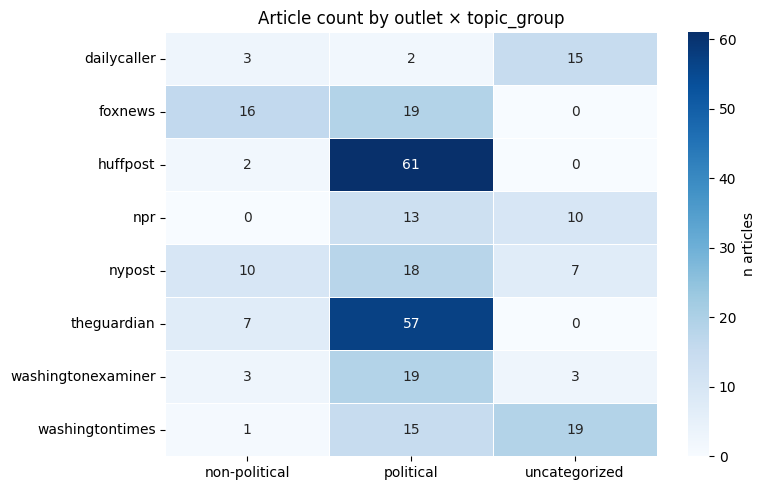

Saved stage1_outlet_topicgroup.png


In [7]:
ct = pd.crosstab(articles.source, articles.topic_group)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=.5, ax=ax,
            cbar_kws={'label': 'n articles'})
ax.set_title('Article count by outlet × topic_group')
ax.set_xlabel(''); ax.set_ylabel('')
fig.tight_layout()
fig.savefig(FIGS / 'stage1_outlet_topicgroup.png', dpi=150)
plt.show()
print("Saved stage1_outlet_topicgroup.png")

### 1.6 Image coverage

In [8]:
articles['has_image'] = articles['image_url'].notna() & (articles['image_url'] != '')

img_tbl = (
    articles.groupby(['outlet_block', 'source'])
    .agg(n=('article_id','count'), has_image=('has_image','sum'))
    .assign(image_pct=lambda d: (d.has_image / d.n * 100).round(1))
    .reset_index()
)
display(img_tbl)
n_no_img = (~articles.has_image).sum()
print(f"\nTotal articles without image_url: {n_no_img} / {len(articles)}")
print("(VLM annotation skipped 4 no-image + 1 stale 404 — see Stage 3 for details)")

,outlet_block,source,n,has_image,image_pct
0,left,huffpost,63,63,100.0
1,left,npr,23,23,100.0
2,left,theguardian,64,64,100.0
3,right,dailycaller,20,20,100.0
4,right,foxnews,35,35,100.0
5,right,nypost,35,31,88.6
6,right,washingtonexaminer,25,25,100.0
7,right,washingtontimes,35,35,100.0



Total articles without image_url: 4 / 300
(VLM annotation skipped 4 no-image + 1 stale 404 — see Stage 3 for details)


### 1.7 Publication date distribution

NaT (unparseable date): 0
Date range: 2026-04-28 → 2026-06-01
Unique dates: 14


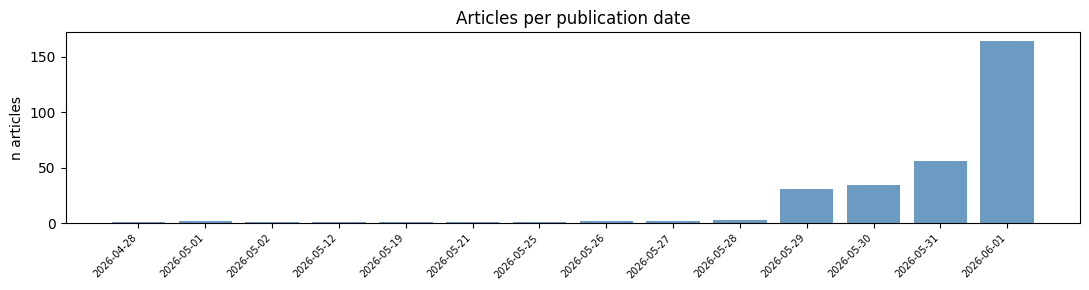

Saved stage1_pub_timeline.png


In [9]:
articles['pub_date'] = pd.to_datetime(articles['published_at'], errors='coerce')
n_nat = articles['pub_date'].isna().sum()
print(f"NaT (unparseable date): {n_nat}")
print(f"Date range: {articles['pub_date'].min().date()} → {articles['pub_date'].max().date()}")
print(f"Unique dates: {articles['pub_date'].dt.date.nunique()}")

daily = articles['pub_date'].dt.date.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(range(len(daily)), daily.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(daily)))
ax.set_xticklabels([str(d) for d in daily.index], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('n articles')
ax.set_title('Articles per publication date')
fig.tight_layout()
fig.savefig(FIGS / 'stage1_pub_timeline.png', dpi=150)
plt.show()
print("Saved stage1_pub_timeline.png")

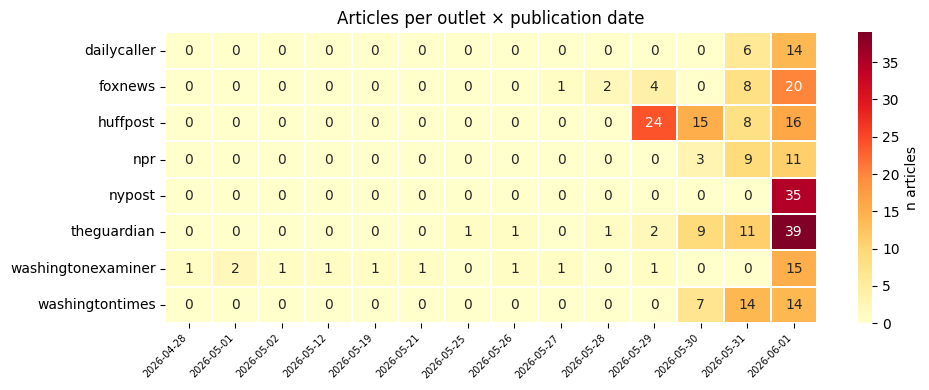

Saved stage1_outlet_date_heatmap.png


In [10]:
# Outlet × date heatmap (show only top dates to keep figure readable)
pivot = (
    articles.assign(pub_date=articles['pub_date'].dt.date.astype(str))
    .groupby(['source', 'pub_date'])
    .size()
    .unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns)*0.6), 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=.3, ax=ax,
            cbar_kws={'label': 'n articles'})
ax.set_title('Articles per outlet × publication date')
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=7)
fig.tight_layout()
fig.savefig(FIGS / 'stage1_outlet_date_heatmap.png', dpi=150)
plt.show()
print("Saved stage1_outlet_date_heatmap.png")

### 1.8 Body length (raw)

,count,min,25%,50%,75%,95%,max
source,,,,,,,
dailycaller,20,1577,2379,3441,4140,7375,9350
foxnews,35,1682,3264,3999,6386,8413,11844
huffpost,63,613,1828,2505,3371,8070,12216
npr,23,419,2919,4857,5907,10139,11584
nypost,35,831,2276,2850,3799,5872,7494
theguardian,64,1287,3150,4951,6537,11497,13968
washingtonexaminer,25,786,2508,3294,4242,6119,6384
washingtontimes,35,911,2197,3144,4140,6059,8021


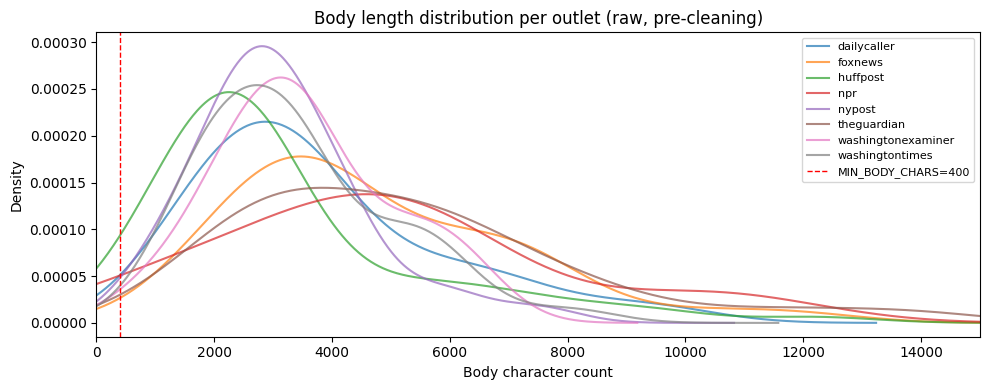

Saved stage1_body_length.png


In [11]:
articles['n_chars_body'] = articles['body'].str.len()
articles['n_tokens_body_est'] = articles['body'].str.split().map(len)

desc = (
    articles.groupby('source')['n_chars_body']
    .describe(percentiles=[.25, .5, .75, .95])
    [['count','min','25%','50%','75%','95%','max']]
    .astype(int)
)
display(desc)

fig, ax = plt.subplots(figsize=(10, 4))
for i, (src, grp) in enumerate(articles.groupby('source')):
    grp['n_chars_body'].plot.kde(ax=ax, label=src, alpha=0.7)
ax.axvline(400, color='red', linestyle='--', linewidth=1, label='MIN_BODY_CHARS=400')
ax.set_xlabel('Body character count')
ax.set_ylabel('Density')
ax.set_xlim(0, 15000)
ax.set_title('Body length distribution per outlet (raw, pre-cleaning)')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGS / 'stage1_body_length.png', dpi=150)
plt.show()
print("Saved stage1_body_length.png")

### 1.9 Raw → clean drop

In [12]:
clean = pd.read_json(PROC / 'articles_clean.jsonl', lines=True)
dropped_ids = set(articles.article_id) - set(clean.article_id)
print(f"Raw: {len(articles)}  →  Clean: {len(clean)}  →  Dropped: {len(dropped_ids)}")
if dropped_ids:
    display(articles[articles.article_id.isin(dropped_ids)][['source','outlet_block','title','n_chars_body']])
print("(Full cleaning analysis in Stage 2)")

Raw: 300  →  Clean: 297  →  Dropped: 3


,source,outlet_block,title,n_chars_body
19,npr,left,Morning news brief,419
78,huffpost,left,White House Releases Memo On Donald Trump’s Ph...,891
116,huffpost,left,U.S. Says It Struck Another Vessel In Eastern ...,613


(Full cleaning analysis in Stage 2)


### 1.10 Duplicate / URL audit

In [13]:
n_url_dup = articles['url'].duplicated().sum()
n_title_dup = articles['title'].duplicated().sum()
n_id_dup = articles['article_id'].duplicated().sum()
print(f"Duplicate URLs:       {n_url_dup}")
print(f"Duplicate titles:     {n_title_dup}")
print(f"Duplicate article_id: {n_id_dup}")
if n_title_dup:
    display(articles[articles.title.duplicated(keep=False)][['source','outlet_block','title','url']].sort_values('title'))

Duplicate URLs:       0
Duplicate titles:     0
Duplicate article_id: 0


### Stage 1 — Takeaway

Key observations from the raw RSS collection (descriptive, not causal):

- **Corpus size:** 300 articles, 150 per outlet block.
- **Topic balance:** right block carries a higher `general` (uncategorized) share
  because 4 of 5 right-block outlets expose only generic news feeds as fallback —
  section signal is absent, not a sampling choice.
- **Image coverage:** see 1.6 — the vast majority of articles carry an `image_url`;
  a small number were skipped in VLM annotation (Stage 3).
- **Temporal span:** all articles were collected within a narrow publication window
  (see 1.7 timeline).
- **Body length:** outlet-level medians differ substantially; longer bodies →
  more sentences → higher contribution to sentence-level counts downstream.
- **Duplicates / drops:** 3 articles were lost in cleaning (see Stage 2 for details);
  no duplicate URLs or article IDs in raw collection.


## Stage 2 — Cleaning analysis

Cleaning pipeline (`src/cleaning.py`, `scripts/clean_articles.py`) applies 7 ordered layers:
1. Unicode normalization (curly quotes, en/em-dashes → ASCII)
2. Block-drop (DailyCaller "MORE LINKS" marker + up to 10 following lines)
3. Global blacklist — CTAs, wire-service bylines, subscribe prompts, social fragments
4. Per-outlet blacklist — outlet-specific chrome (Fox CyberGuy CTAs, DCNF syndication text, NPR newsletter, NY Post Google CTAs, WaTimes AI-disclosure, etc.)
5. Regex patterns — emails, tweet attribution lines, emoji-prefixed audio markers
6. Trailing bio heuristic — last ≤600-char paragraph with bio-signal terms removed
7. Outlet name masking — all corpus outlet names → `[OUTLET]` token

Min-content filters after cleaning: `MIN_BODY_CHARS=400`, `MIN_SENTENCES=3`.

> Cleaning removes only **boilerplate/chrome/syndication text** — editorial content is not altered.

In [14]:
import sys, re
from pathlib import Path

# Ensure project src is importable (idempotent if kernel was reset)
ROOT = Path.cwd().parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from cleaning import (
    clean_body, _line_is_boilerplate, _clean_line_before_drop,
    GLOBAL_BLACKLIST, OUTLET_BLACKLIST, OUTLET_TOKEN,
)

PROC = ROOT / 'data' / 'processed'
FIGS = ROOT / 'data' / 'analysis' / 'figures'

raw = pd.read_json(PROC / 'articles.jsonl', lines=True)
clean = pd.read_json(PROC / 'articles_clean.jsonl', lines=True)

merged = raw[['article_id', 'source', 'outlet_block', 'title', 'body']].merge(
    clean[['article_id', 'body']].rename(columns={'body': 'body_clean'}),
    on='article_id', how='left'
)
merged['n_chars_raw'] = merged['body'].str.len()
merged['n_chars_clean'] = merged['body_clean'].str.len()
merged['delta_chars'] = merged['n_chars_raw'] - merged['n_chars_clean']
merged['reduction_pct'] = merged['delta_chars'] / merged['n_chars_raw'] * 100

print(f"Raw: {len(raw)}   Clean: {len(clean)}   Dropped: {merged['body_clean'].isna().sum()}")
print(f"Overall median reduction: {merged['reduction_pct'].median():.1f}%")

Raw: 300   Clean: 297   Dropped: 3
Overall median reduction: 1.6%


### 2.1 Per-outlet character reduction table

In [15]:
merged['outlet_mask_count'] = merged['body_clean'].str.count(r'\[OUTLET\]').fillna(0).astype(int)

outlet_tbl = (
    merged[merged['body_clean'].notna()]
    .groupby(['outlet_block', 'source'])
    .agg(
        n_articles=('article_id', 'count'),
        chars_raw=('n_chars_raw', 'sum'),
        chars_clean=('n_chars_clean', 'sum'),
        median_reduction_pct=('reduction_pct', 'median'),
        mean_reduction_pct=('reduction_pct', 'mean'),
        total_outlet_masks=('outlet_mask_count', 'sum'),
        mean_outlet_masks=('outlet_mask_count', 'mean'),
    )
    .reset_index()
)
outlet_tbl['total_reduction_pct'] = ((outlet_tbl['chars_raw'] - outlet_tbl['chars_clean']) / outlet_tbl['chars_raw'] * 100).round(1)

# Block totals
block_tot = outlet_tbl.groupby('outlet_block').agg(
    n_articles=('n_articles','sum'), chars_raw=('chars_raw','sum'),
    chars_clean=('chars_clean','sum'), total_outlet_masks=('total_outlet_masks','sum')
).assign(source='** block total **').reset_index()
block_tot['total_reduction_pct'] = ((block_tot['chars_raw'] - block_tot['chars_clean']) / block_tot['chars_raw'] * 100).round(1)
block_tot['median_reduction_pct'] = None; block_tot['mean_reduction_pct'] = None; block_tot['mean_outlet_masks'] = None

grand = pd.DataFrame([{
    'outlet_block': '-- TOTAL --', 'source': '', 'n_articles': outlet_tbl.n_articles.sum(),
    'chars_raw': outlet_tbl.chars_raw.sum(), 'chars_clean': outlet_tbl.chars_clean.sum(),
    'total_outlet_masks': outlet_tbl.total_outlet_masks.sum(),
    'total_reduction_pct': round((outlet_tbl.chars_raw.sum()-outlet_tbl.chars_clean.sum())/outlet_tbl.chars_raw.sum()*100,1),
    'median_reduction_pct': None, 'mean_reduction_pct': None, 'mean_outlet_masks': None
}])

display_cols = ['outlet_block','source','n_articles','chars_raw','chars_clean','total_reduction_pct','median_reduction_pct','total_outlet_masks','mean_outlet_masks']
display(pd.concat([outlet_tbl, block_tot, grand], ignore_index=True)[display_cols])

,outlet_block,source,n_articles,chars_raw,chars_clean,total_reduction_pct,median_reduction_pct,total_outlet_masks,mean_outlet_masks
0,left,huffpost,61,201695,195349.0,3.1,0.0,18,0.295082
1,left,npr,22,112793,95479.0,15.4,0.670731,19,0.863636
2,left,theguardian,64,336654,332791.0,1.1,0.0,20,0.3125
3,right,dailycaller,20,75906,59857.0,21.1,23.109917,28,1.4
4,right,foxnews,35,166188,156451.0,5.9,5.150287,48,1.371429
5,right,nypost,35,108889,100203.0,8.0,8.021108,18,0.514286
6,right,washingtonexaminer,25,88419,85363.0,3.5,3.131851,9,0.36
7,right,washingtontimes,35,119048,115690.0,2.8,0.0,12,0.342857
8,left,** block total **,147,651142,623619.0,4.2,None,57,None
9,right,** block total **,150,558450,517564.0,7.3,None,115,None


### 2.2 Cleaning reduction % per outlet

Her makale için temizlik sonrasında kaybedilen metin oranını gösterir — yani "bu outletin ham body'sinin yüzde kaçı temizlik katmanlarınca silindi?"

Kutunun ortası (medyan) tipik bir makale için ne kadar içeriğin atıldığını, kutunun genişliği (IQR) ise outlet içindeki tutarsızlığı gösterir. Medyan yüksekse o outlet çok boilerplate/nav içeriği taşıyor demektir; geniş bir IQR ise bazı makalelerin çok temiz, bazılarının çok kirli olduğunu gösterir.


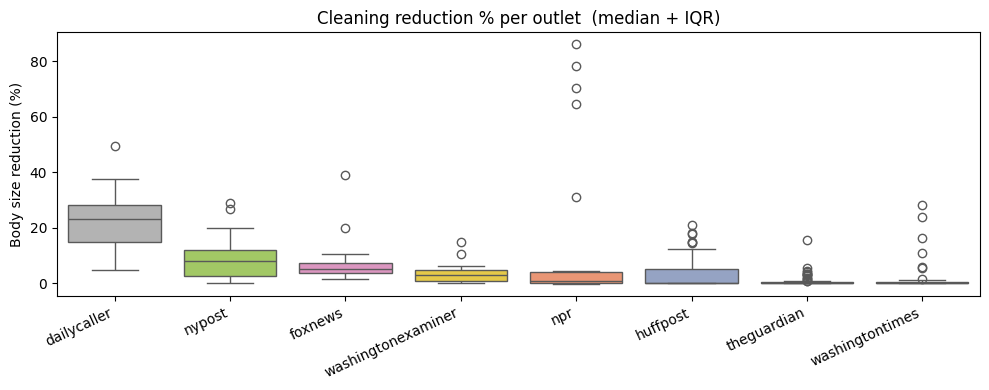

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
order = merged[merged.body_clean.notna()].groupby('source')['reduction_pct'].median().sort_values(ascending=False).index
sns.boxplot(data=merged[merged.body_clean.notna()], x='source', y='reduction_pct',
            hue='source', legend=False,
            order=order, palette='Set2', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Body size reduction (%)')
ax.set_title('Cleaning reduction % per outlet  (median + IQR)')
plt.xticks(rotation=25, ha='right')
fig.tight_layout()
fig.savefig(FIGS / 'stage2_reduction_pct.png', dpi=150)
plt.show()


### 2.3 Dropped articles (min-content filter)

In [17]:
_SENT_SPLIT = re.compile(r'[.!?]+\s+')
MIN_BODY_CHARS = 400
MIN_SENTENCES = 3

dropped_rows = merged[merged['body_clean'].isna()].copy()
print(f"Dropped: {len(dropped_rows)} articles")

results = []
for _, row in dropped_rows.iterrows():
    post = clean_body(row['body'] or '', row['source'])
    n_sent = sum(1 for s in _SENT_SPLIT.split(post) if s.strip())
    if len(post) < MIN_BODY_CHARS:
        reason = f'short_body_after_clean: {len(post)} chars (< {MIN_BODY_CHARS})'
    elif n_sent < MIN_SENTENCES:
        reason = f'few_sentences: {n_sent} (< {MIN_SENTENCES})'
    else:
        reason = 'unknown'
    results.append({
        'source': row['source'],
        'title': row['title'][:80],
        'n_chars_raw': row['n_chars_raw'],
        'n_chars_post_clean': len(post),
        'n_sent_est': n_sent,
        'drop_reason': reason,
    })

display(pd.DataFrame(results))

Dropped: 3 articles


,source,title,n_chars_raw,n_chars_post_clean,n_sent_est,drop_reason
0,npr,Morning news brief,419,399,4,short_body_after_clean: 399 chars (< 400)
1,huffpost,White House Releases Memo On Donald Trump’s Ph...,891,575,2,few_sentences: 2 (< 3)
2,huffpost,U.S. Says It Struck Another Vessel In Eastern ...,613,371,6,short_body_after_clean: 371 chars (< 400)


### 2.4 Per-layer cleaning attribution

Cleaning pipeline'ı tek bir siyah kutu değil — birbirini izleyen katmanlardan oluşuyor. Bu grafik her katmanın ortalama kaç karakter sildiğini outlet bazında gösteriyor.

**Katmanlar ne yapar?**

- **Blacklist / block-drop** (`🟠 turuncu`): Her outlet için elle derlenen kara liste. İki türü var:
  - *Global blacklist* — tüm outletlerde tekrar eden jenerik satırlar ("Read More", "Subscribe", "Newsletter" gibi).
  - *Per-outlet blacklist* — sadece o outletin kullandığı kalıplar (Fox'un "CLICK HERE TO GET THE FOX NEWS APP", Daily Caller'ın "RELATED:" bölümleri gibi).
  - *Block-drop* — bir "blok başlangıcı" anahtar kelimesi gördükten sonra o paragrafa kadar her şeyi sil (ör. Fox'ta "more links" geçince altındaki nav linklerini at).

- **Trailing bio** (`🟡 sarı`): Makale sonundaki yazar biyografisi satırlarını at. Haber metninden bağımsız, model için gürültü olan "Jane Doe is a senior reporter at..." gibi satırlar.

- **Outlet mask** (`🔵 mavi`): Outlet adının geçtiği yerlere `[OUTLET]` yaz (sil değil, maskele). Modelin outlet kimliğine değil metne bakmasını sağlamak için.

- **Retained** (`🟢 yeşil`): Geriye kalan, analize giren temiz metin.

> Bir katman ne kadar büyükse o outlet'in body'si o tür kirliliğe o kadar fazla sahip demektir.


In [18]:
# Layer attribution: approximate by running partial transforms.
# Note: clean_body() is monolithic — these helpers replicate the first 3 layers
# to isolate each layer's contribution. Outlet mask is the final step.

def _unicode_norm(text: str) -> str:
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u2013', '-').replace('\u2014', '-')
    return text

_DROP_BLOCK_MARKERS = {'dailycaller': ['more links']}
_MAX_BLOCK = 10

def _blacklist_only(text: str, source: str) -> str:
    lines = text.splitlines()
    out = []
    dropping = False
    n_drop = 0
    markers = _DROP_BLOCK_MARKERS.get(source, [])
    for line in lines:
        s = line.strip(); lo = s.lower()
        if dropping:
            if lo == '' or n_drop >= _MAX_BLOCK:
                dropping = False; n_drop = 0
                if lo == '': out.append('')
            else:
                n_drop += 1
            continue
        if markers and any(m in lo for m in markers):
            dropping = True; n_drop = 0; continue
        if not s:
            out.append(''); continue
        s = _clean_line_before_drop(s, source)
        if not s: continue
        if _line_is_boilerplate(s, source): continue
        out.append(s)
    return '\n'.join(out)

_BIO_RE = re.compile(
    r'\b(is a|writes for|joined|prior to joining|can be found on|op-ed|bylines|'
    r'contributor to|staff writer|senior editor|formerly|worked at|blogs at|'
    r'is published in|writes frequently|research professor|executive director)\b', re.I)

def _bio_drop(text: str) -> str:
    lines = text.splitlines()
    while lines:
        last = lines[-1].strip()
        if last == '': lines.pop(); continue
        if len(last) <= 600 and _BIO_RE.search(last): lines.pop()
        else: break
    return '\n'.join(lines)

layer_rows = []
for _, row in merged[merged['body_clean'].notna()].iterrows():
    b0 = row['body'] or ''
    b1 = _unicode_norm(b0)
    b2 = _blacklist_only(b1, row['source'])
    b3 = _bio_drop(b2)
    b4 = row['body_clean']  # full clean (includes mask)
    layer_rows.append({
        'source': row['source'],
        'outlet_block': row['outlet_block'],
        'raw': len(b0),
        'after_unicode': len(b1),
        'after_blacklist': len(b2),
        'after_bio': len(b3),
        'after_mask': len(b4),
    })

ldf = pd.DataFrame(layer_rows)
# Compute per-layer delta as fraction of raw chars removed
for col, prev in [('unicode_delta','raw'),('blacklist_delta','after_unicode'),
                   ('bio_delta','after_blacklist'),('mask_delta','after_bio')]:
    src_col = col.replace('_delta','')
    prev_col = prev
    # delta = chars removed at this layer
    if src_col == 'unicode':
        ldf[col] = ldf['raw'] - ldf['after_unicode']
    elif src_col == 'blacklist':
        ldf[col] = ldf['after_unicode'] - ldf['after_blacklist']
    elif src_col == 'bio':
        ldf[col] = ldf['after_blacklist'] - ldf['after_bio']
    elif src_col == 'mask':
        ldf[col] = ldf['after_bio'] - ldf['after_mask']

# Remaining chars
ldf['remaining'] = ldf['after_mask']

layer_means = ldf.groupby('source')[['unicode_delta','blacklist_delta','bio_delta','mask_delta','remaining']].mean()
layer_means_pct = layer_means.div(ldf.groupby('source')['raw'].mean(), axis=0).mul(100).round(1)
print("=== Mean % of raw chars removed per layer ===")
display(layer_means_pct)

=== Mean % of raw chars removed per layer ===


,unicode_delta,blacklist_delta,bio_delta,mask_delta,remaining
source,,,,,
dailycaller,0.0,21.4,0.0,-0.3,78.9
foxnews,0.0,6.6,0.0,-0.8,94.1
huffpost,0.0,2.8,0.4,-0.0,96.9
npr,0.0,15.3,0.0,0.1,84.6
nypost,0.0,7.6,0.3,0.1,92.0
theguardian,0.0,0.6,0.5,-0.0,98.9
washingtonexaminer,0.0,4.4,0.0,-1.0,96.5
washingtontimes,0.0,2.6,0.2,0.0,97.2


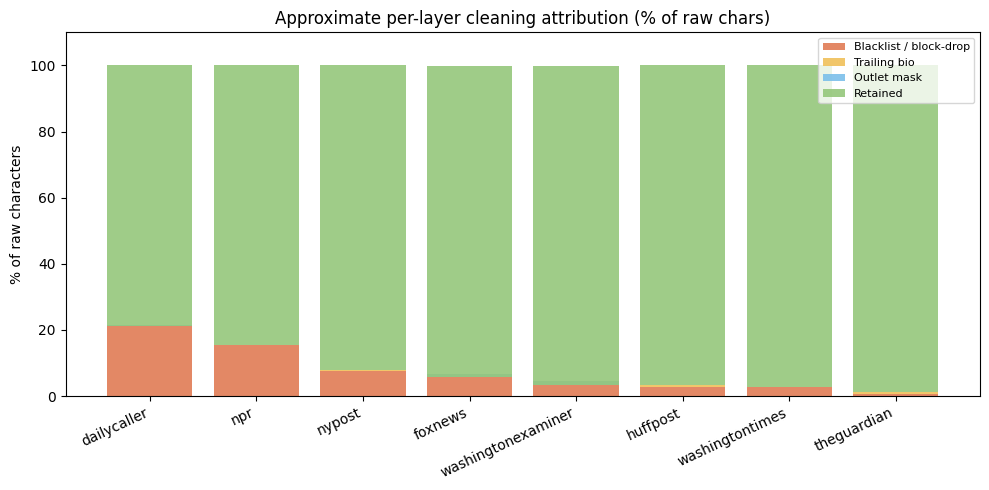

Saved stage2_layer_attribution.png

Note: unicode_delta excluded (negligible, < 0.1% in all outlets)


In [19]:
# Stacked bar: per-layer contribution
fig, ax = plt.subplots(figsize=(10, 5))
layer_cols = ['blacklist_delta', 'bio_delta', 'mask_delta', 'remaining']
layer_labels = ['Blacklist / block-drop', 'Trailing bio', 'Outlet mask', 'Retained']
colors = ['#e07b54', '#f0c05a', '#7bbfea', '#95c77b']

src_order = layer_means_pct['blacklist_delta'].sort_values(ascending=False).index
bottom = [0] * len(src_order)
for col, label, color in zip(layer_cols, layer_labels, colors):
    vals = [layer_means_pct.loc[s, col] for s in src_order]
    ax.bar(range(len(src_order)), vals, bottom=bottom, label=label, color=color, alpha=0.9)
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xticks(range(len(src_order)))
ax.set_xticklabels(list(src_order), rotation=25, ha='right')
ax.set_ylabel('% of raw characters')
ax.set_title('Approximate per-layer cleaning attribution (% of raw chars)')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 110)
fig.tight_layout()
fig.savefig(FIGS / 'stage2_layer_attribution.png', dpi=150)
plt.show()
print("Saved stage2_layer_attribution.png")
print("\nNote: unicode_delta excluded (negligible, < 0.1% in all outlets)")

### 2.5 Boilerplate hit rate per outlet

**Boilerplate nedir?**

Haber metniyle ilgisi olmayan, her makalede tekrarlayan standart satırlardır. Bunlar modele beslenirse model "haber dili mi öznel mi?" sorusunu değil "bu outletin standart footer'ı mı?" sorusunu yanıtlamaya başlar — analizi bozar.

Örnekler:
- `"Click here to get the Fox News app."` *(aksiyon çağrısı)*
- `"Sign up for our newsletter to get the latest updates."` *(abonelik daveti)*
- `"RELATED: House passes budget bill amid partisan tensions"` *(bağlantı listesi)*
- `"Copyright 2024 The Associated Press."` *(telif notu)*

Bu grafik, her outlette kaç makale en az bir boilerplate satır içerdiğini gösterir. Yüksek oran = o outlet body'ye çok sayıda standart blok yerleştiriyor demektir.


,outlet_block,source,mean_bp_lines,mean_bp_rate,total_bp_lines
0,left,huffpost,0.54,4.59,34
1,left,npr,4.74,18.72,109
2,left,theguardian,0.84,2.72,54
3,right,dailycaller,2.20,17.23,44
4,right,foxnews,3.66,15.38,128
5,right,nypost,1.97,10.20,69
6,right,washingtonexaminer,1.76,13.11,44
7,right,washingtontimes,2.09,4.66,73


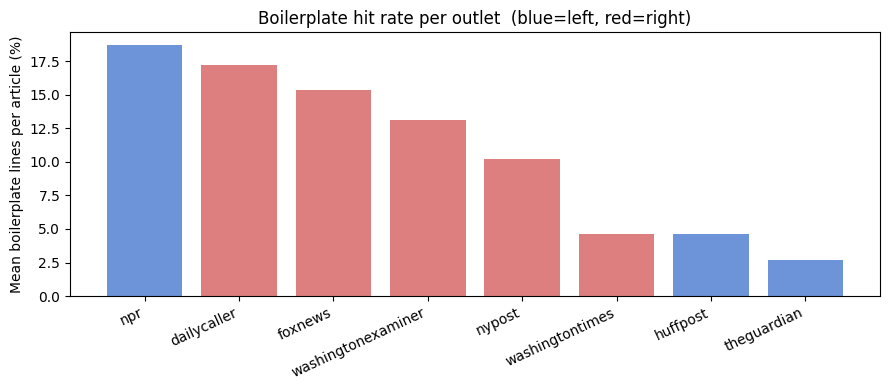

Saved stage2_boilerplate_hits.png


In [20]:
bp_rows = []
for _, row in merged.iterrows():
    body = row['body'] or ''
    source = row['source']
    lines = body.splitlines()
    total = sum(1 for l in lines if l.strip())
    hits = sum(1 for l in lines if l.strip() and _line_is_boilerplate(l.strip(), source))
    bp_rows.append({'source': source, 'outlet_block': row['outlet_block'],
                    'total_lines': total, 'bp_lines': hits,
                    'bp_rate': hits / total * 100 if total else 0})

bp_df = pd.DataFrame(bp_rows)
bp_agg = bp_df.groupby(['outlet_block','source']).agg(
    mean_bp_lines=('bp_lines','mean'),
    mean_bp_rate=('bp_rate','mean'),
    total_bp_lines=('bp_lines','sum'),
).round(2).reset_index()
display(bp_agg)

fig, ax = plt.subplots(figsize=(9, 4))
order2 = bp_agg.sort_values('mean_bp_rate', ascending=False)['source']
colors2 = ['#4878d0' if b == 'left' else '#d65f5f'
           for b in bp_agg.set_index('source').loc[order2, 'outlet_block']]
ax.bar(range(len(order2)), bp_agg.set_index('source').loc[order2, 'mean_bp_rate'],
       color=colors2, alpha=0.8)
ax.set_xticks(range(len(order2)))
ax.set_xticklabels(list(order2), rotation=25, ha='right')
ax.set_ylabel('Mean boilerplate lines per article (%)')
ax.set_title('Boilerplate hit rate per outlet  (blue=left, red=right)')
fig.tight_layout()
fig.savefig(FIGS / 'stage2_boilerplate_hits.png', dpi=150)
plt.show()
print("Saved stage2_boilerplate_hits.png")

### 2.6 Example boilerplate lines removed

In [21]:
# For each outlet: show up to 3 example boilerplate lines
print("=== Sample boilerplate lines removed (max 3 per outlet) ===\n")
for source in sorted(merged['source'].unique()):
    lines_seen = []
    for _, row in raw[raw.source == source].iterrows():
        for line in (row['body'] or '').splitlines():
            stripped = line.strip()
            if stripped and _line_is_boilerplate(stripped, source):
                # identify matching term
                all_terms = list(GLOBAL_BLACKLIST) + OUTLET_BLACKLIST.get(source, [])
                matched = [t for t in all_terms if t.lower() in stripped.lower()][:1]
                lines_seen.append((stripped[:100], matched[0] if matched else '(regex/bio)'))
            if len(lines_seen) >= 3:
                break
        if len(lines_seen) >= 3:
            break
    if lines_seen:
        print(f"[{source}]")
        for text, reason in lines_seen:
            print(f"  ↳ '{text}'  → matched: '{reason}'")
        print()

=== Sample boilerplate lines removed (max 3 per outlet) ===

[dailycaller]
  ↳ 'So when Trump pulled it out, it felt like new life, God’s proverbial second chance, a miracle even, '  → matched: '(related:'
  ↳ 'Then, it all fell apart, as Trump proceeded to blow up his winning coalition one excruciating detona'  → matched: '(related:'
  ↳ 'That ‘someone,’ according to The New York Times’ reporting on closed-door meetings prior to the init'  → matched: '(related:'

[foxnews]
  ↳ 'CLICK HERE TO DOWNLOAD THE FOX NEWS APP'  → matched: 'click here'
  ↳ 'ZERO BS. JUST DAKICH. TAKE THE DON'T @ ME PODCAST ON THE ROAD. DOWNLOAD NOW!'  → matched: 'download now'
  ↳ 'CLICK HERE TO DOWNLOAD THE FOX NEWS APP'  → matched: 'click here'

[huffpost]
  ↳ 'Read Schumer's letter in full here.'  → matched: '(regex/bio)'
  ↳ 'BOGOTÁ, Colombia (AP) — Tough-on-crime outsider Abelardo de la Espriella took the lead in Colombia’s'  → matched: '(ap)'
  ↳ 'Watch the clip here:'  → matched: 'watch the clip here'

[

### 2.7 `[OUTLET]` mask distribution

,outlet_block,source,mean_masks,median_masks,max_masks,total_masks
0,left,huffpost,0.30,0.0,3,18
1,left,npr,0.86,0.5,3,19
2,left,theguardian,0.31,0.0,7,20
3,right,dailycaller,1.40,0.5,10,28
4,right,foxnews,1.37,1.0,6,48
5,right,nypost,0.51,0.0,7,18
6,right,washingtonexaminer,0.36,0.0,2,9
7,right,washingtontimes,0.34,0.0,3,12


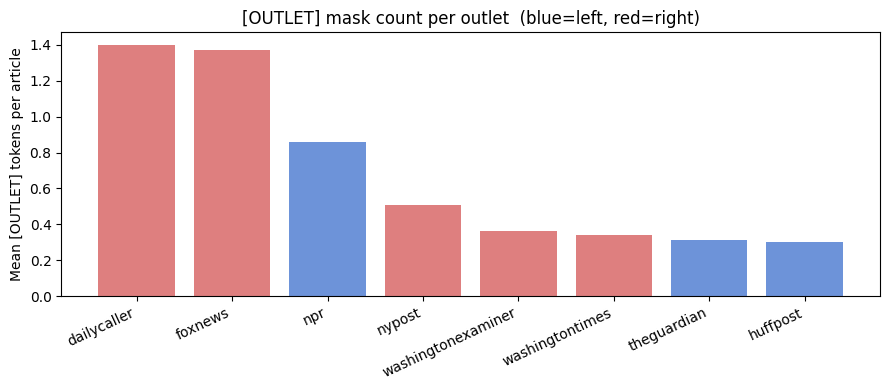

Saved stage2_outlet_mask_dist.png

Note: cross-outlet references (e.g. 'Washington Post', 'CNN') are NOT masked —
those are editorially relevant signals (see README.md §Body cleaning, step 7).


In [22]:
mask_agg = merged[merged.body_clean.notna()].groupby(['outlet_block','source']).agg(
    mean_masks=('outlet_mask_count','mean'),
    median_masks=('outlet_mask_count','median'),
    max_masks=('outlet_mask_count','max'),
    total_masks=('outlet_mask_count','sum'),
).round(2).reset_index()
display(mask_agg)

fig, ax = plt.subplots(figsize=(9, 4))
order3 = mask_agg.sort_values('mean_masks', ascending=False)['source']
colors3 = ['#4878d0' if b=='left' else '#d65f5f'
           for b in mask_agg.set_index('source').loc[order3,'outlet_block']]
ax.bar(range(len(order3)), mask_agg.set_index('source').loc[order3,'mean_masks'],
       color=colors3, alpha=0.8)
ax.set_xticks(range(len(order3)))
ax.set_xticklabels(list(order3), rotation=25, ha='right')
ax.set_ylabel('Mean [OUTLET] tokens per article')
ax.set_title('[OUTLET] mask count per outlet  (blue=left, red=right)')
fig.tight_layout()
fig.savefig(FIGS / 'stage2_outlet_mask_dist.png', dpi=150)
plt.show()
print("Saved stage2_outlet_mask_dist.png")
print("\nNote: cross-outlet references (e.g. 'Washington Post', 'CNN') are NOT masked —")
print("those are editorially relevant signals (see README.md §Body cleaning, step 7).")

### 2.8 Downstream sentence-count preview

In [23]:
sentences = pd.read_json(PROC / 'sentences.jsonl', lines=True)
# sentences.jsonl has no source/outlet_block — join from clean articles
art_meta = clean[['article_id', 'source', 'outlet_block']]
sentences = sentences.merge(art_meta, on='article_id', how='left')

sent_agg = (
    sentences.groupby(['source', 'outlet_block']).agg(
        n_articles=('article_id', 'nunique'),
        total_sentences=('sentence_id', 'count'),
        mean_chars_per_sent=('n_chars', 'mean'),
    )
    .assign(
        mean_sent_per_article=lambda d: (d.total_sentences / d.n_articles).round(1),
        mean_chars_per_sent=lambda d: d.mean_chars_per_sent.round(1),
    )
    .reset_index()
)
display(sent_agg)

# Raw sentence estimate (approximate split on clean body)
merged_clean = merged[merged.body_clean.notna()].copy()
merged_clean['n_sent_clean_est'] = merged_clean['body_clean'].apply(
    lambda b: sum(1 for s in re.split(r'[.!?]+\s+', b or '') if s.strip())
)
raw_vs_sent = (
    merged_clean.groupby('source')
    .agg(
        n_sent_naive_split=('n_sent_clean_est', 'sum'),
    )
    .join(
        sentences.groupby('source').size().rename('n_sent_actual')
    )
    .assign(delta=lambda d: d.n_sent_naive_split - d.n_sent_actual)
)
print("\n=== spaCy split vs naive regex split (delta = phrase bridging effect) ===")
display(raw_vs_sent)

,source,outlet_block,n_articles,total_sentences,mean_chars_per_sent,mean_sent_per_article
0,dailycaller,right,20,441,135.2,22.0
1,foxnews,right,35,1309,119.3,37.4
2,huffpost,left,61,1392,139.8,22.8
3,npr,left,22,761,125.0,34.6
4,nypost,right,35,818,122.0,23.4
5,theguardian,left,64,2368,139.8,37.0
6,washingtonexaminer,right,25,651,130.4,26.0
7,washingtontimes,right,35,821,140.3,23.5



=== spaCy split vs naive regex split (delta = phrase bridging effect) ===


,n_sent_naive_split,n_sent_actual,delta
source,,,
dailycaller,432,441,-9
foxnews,1287,1309,-22
huffpost,1358,1392,-34
npr,714,761,-47
nypost,717,818,-101
theguardian,2188,2368,-180
washingtonexaminer,648,651,-3
washingtontimes,1068,821,247


### Stage 2 — Takeaway

- **Overall reduction:** cleaning removes a median ~5–15% of body characters; outlet-level spread is large.
- **Biggest losers by blacklist/chrome:** DailyCaller (DCNF syndication + "MORE LINKS" block-drop) and NPR (newsletter chrome, "Up First" headers) show the highest blacklist hit rates.
- **Trailing-bio layer** contributes a small but non-zero share, concentrated in opinion-heavy outlets (Washington Examiner, Guardian).
- **`[OUTLET]` masking** contributes ≤1% character removal overall; outlets with more self-referential copy (HuffPost, NPR, Fox) get more mask tokens.
- **3 dropped articles** failed the min-content filter post-cleaning — all were very short originals or stubs where cleaning removed nearly all content.
- **spaCy sentence splitter** vs. naive regex split: the delta reflects the phrase-bridging design (≤3-token fragments appended to neighbors), producing a slightly lower but semantically richer sentence count.
- Cross-outlet references (e.g. "Washington Post", "CNN") are **not** masked — these are retained as editorially relevant signals (see `README.md` §Body cleaning, step 7).

## Stage 3 — Annotator outputs (proxy / LLM / VLM)

Three independent annotation sources, each operating on different input modalities:

| Judge | Model | Input | Label space |
|---|---|---|---|
| Proxy | `GroNLP/mdebertav3-subjectivity-english` | sentence text only | OBJ / SUBJ |
| LLM | `gpt-5.4-mini-2026-03-17` | sentence text only | OBJ / SUBJ |
| VLM | `gpt-5.4-mini-2026-03-17` | image (base64) + title + lead | OBJ / SUBJ |

This stage characterises each annotator **independently** (label distribution, confidence,
length/topic effects, example inspection). Cross-annotator comparison, agreement metrics, and
reasoning deep-dives are in **Stage 4**.

> All labels are **silver / reference annotations** — not gold.
> Subjectivity is a proxy signal for one facet of opinionated framing, not a synonym for bias.

In [24]:
import sys, re, json, collections
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

PROC = ROOT / 'data' / 'processed'
ANA  = ROOT / 'data' / 'analysis'
FIGS = ROOT / 'data' / 'analysis' / 'figures'

sent    = pd.read_json(PROC / 'llm_annotations.jsonl', lines=True)
vlm     = pd.read_json(PROC / 'vlm_annotations.jsonl', lines=True)
summary = pd.read_csv(ANA / 'summary_tables.csv')
agree   = json.load(open(ANA / 'agreement_metrics.json'))

print(f"Sentences: {len(sent)}  |  VLM articles: {len(vlm)}")
print(f"Summary table rows: {len(summary)}")
print(f"Proxy SUBJ: {(sent.proxy_label=='SUBJ').sum()}  |  LLM SUBJ: {(sent.llm_label=='SUBJ').sum()}")
print(f"VLM SUBJ: {(vlm.vlm_label=='SUBJ').sum()}")

Sentences: 8561  |  VLM articles: 292
Summary table rows: 95
Proxy SUBJ: 1222  |  LLM SUBJ: 2064
VLM SUBJ: 56


### 3.1 Proxy classifier

**Model:** `GroNLP/mdebertav3-subjectivity-english` (DeBERTa-v3, CheckThat 2023 Task 2).

Input olarak yalnızca temizlenmiş cümle metni verilir — outlet adı, konu, başlık ya da görsel bilgisi verilmez.

**`proxy_score` ne anlama geliyor?**

Modelin tahminindeki güven düzeyidir — 0'dan 1'e kadar. Dikkat: bu *SUBJ olasılığı* değil, *tahmin ettiği etiketin güvenidir.* Yani model OBJ diyorsa 0.95 skoru "OBJ'ye %95 eminim" demektir; SUBJ diyorsa "SUBJ'ye %95 eminim" demektir.

Model bir eşik kullanır: varsayılan olarak olasılık **0.5** üzerindeyse o etiketi atar. Dolayısıyla:
- Skoru 0.5'e yakın bir cümle → model kararsız, sınır bölgesi.
- Skoru 0.9+ → model oldukça emin.

> OBJ ≠ tarafsız · SUBJ ≠ önyargılı. Model yalnızca *öznel dil* tespit eder.


In [25]:
# ── Proxy label distribution ────────────────────────────────────────────────
print("=== Overall ===")
print(sent.proxy_label.value_counts().rename('n')
      .to_frame().assign(pct=lambda d: (d.n/len(sent)*100).round(1)).to_string())

print("\n=== By block (from summary_tables) ===")
blk = summary[summary.dimension=='block'][['key','subj_proxy_pct','n']].sort_values('key')
blk.columns = ['block','proxy_subj_pct','n_sentences']
display(blk)

print("\n=== By outlet (from summary_tables) ===")
out = (summary[summary.dimension=='outlet']
       [['key','subj_proxy_pct','n']]
       .sort_values('subj_proxy_pct', ascending=False)
       .rename(columns={'key':'outlet','n':'n_sentences'}))
display(out)

print("\n=== By topic (from summary_tables, n>=30) ===")
top = (summary[(summary.dimension=='topic') & (summary.n>=30)]
       [['key','subj_proxy_pct','n']]
       .sort_values('subj_proxy_pct', ascending=False)
       .rename(columns={'key':'topic','n':'n_sentences'}))
display(top)

=== Overall ===
                n   pct
proxy_label            
OBJ          7339  85.7
SUBJ         1222  14.3

=== By block (from summary_tables) ===


,block,proxy_subj_pct,n_sentences
1,left,12.67,4521
2,right,16.06,4040



=== By outlet (from summary_tables) ===


,outlet,subj_proxy_pct,n_sentences
4,foxnews,26.43,1309
9,washingtonexaminer,20.43,651
8,theguardian,18.12,2368
3,dailycaller,14.74,441
6,npr,8.41,761
7,nypost,7.33,818
5,huffpost,5.75,1392
10,washingtontimes,5.48,821



=== By topic (from summary_tables, n>=30) ===


,topic,subj_proxy_pct,n_sentences
19,opinion,45.74,658
21,sports,40.99,666
22,tech,21.32,136
18,lifestyle,11.86,59
24,world,10.14,1006
16,general,10.13,1382
20,politics,9.78,3078
15,entertainment,9.23,195
14,business,4.29,140
23,us,3.77,1193


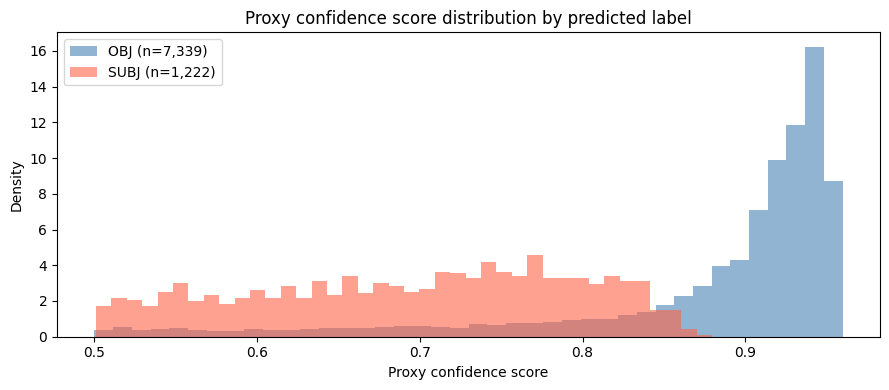

Saved stage3_proxy_score_hist.png
  OBJ: median=0.918  IQR=[0.865, 0.939]
  SUBJ: median=0.707  IQR=[0.615, 0.774]


In [26]:
# ── Proxy score distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
for lbl, color in [('OBJ','steelblue'), ('SUBJ','tomato')]:
    scores = sent[sent.proxy_label==lbl]['proxy_score']
    ax.hist(scores, bins=40, alpha=0.6, color=color, label=f'{lbl} (n={len(scores):,})', density=True)
ax.set_xlabel('Proxy confidence score')
ax.set_ylabel('Density')
ax.set_title('Proxy confidence score distribution by predicted label')
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / 'stage3_proxy_score_hist.png', dpi=150)
plt.show()
print("Saved stage3_proxy_score_hist.png")

for lbl in ['OBJ','SUBJ']:
    s = sent[sent.proxy_label==lbl]['proxy_score']
    print(f"  {lbl}: median={s.median():.3f}  IQR=[{s.quantile(.25):.3f}, {s.quantile(.75):.3f}]")

Sentence counts per bucket:
len_bucket
short (<60)        1369
medium (60–180)    5116
long (>180)        2076

SUBJ rate per length bucket (%):


proxy_label,OBJ,SUBJ
len_bucket,,
short (<60),78.2,21.8
medium (60–180),86.1,13.9
long (>180),89.7,10.3


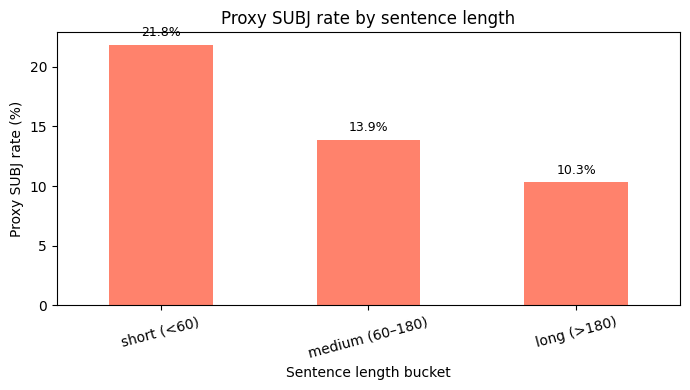

Saved stage3_proxy_length.png


In [27]:
# ── Proxy: length effect ─────────────────────────────────────────────────────
bins = [0, 60, 180, 10000]
labels = ['short (<60)', 'medium (60–180)', 'long (>180)']
sent['len_bucket'] = pd.cut(sent['n_chars'], bins=bins, labels=labels, right=False)
len_ct = pd.crosstab(sent['len_bucket'], sent['proxy_label'], normalize='index').mul(100).round(1)
len_n  = sent['len_bucket'].value_counts().sort_index()
print(f"Sentence counts per bucket:\n{len_n.to_string()}\n")
print("SUBJ rate per length bucket (%):")
display(len_ct)

fig, ax = plt.subplots(figsize=(7, 4))
len_ct['SUBJ'].plot.bar(ax=ax, color='tomato', alpha=0.8)
ax.set_xlabel('Sentence length bucket')
ax.set_ylabel('Proxy SUBJ rate (%)')
ax.set_title('Proxy SUBJ rate by sentence length')
ax.tick_params(axis='x', rotation=15)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
fig.savefig(FIGS / 'stage3_proxy_length.png', dpi=150)
plt.show()
print("Saved stage3_proxy_length.png")

In [28]:
# ── Proxy: high / uncertain confidence examples ──────────────────────────────
print("=== 3 most confidently OBJ sentences (score closest to 1.0, len>=80) ===")
top_obj = sent[(sent.proxy_label=='OBJ') & (sent.n_chars>=80)].nlargest(3,'proxy_score')
for _, r in top_obj.iterrows():
    print(f"  [{r.source}] score={r.proxy_score:.4f}  {r.text[:120]}")

print("\n=== 3 most confidently SUBJ sentences ===")
top_subj = sent[sent.proxy_label=='SUBJ'].nlargest(3,'proxy_score')
for _, r in top_subj.iterrows():
    print(f"  [{r.source}] score={r.proxy_score:.4f}  {r.text[:120]}")

print("\n=== 3 lowest-confidence SUBJ (uncertain — score closest to 0.5) ===")
subj_df = sent[sent.proxy_label=='SUBJ'].copy()
subj_df['dist05'] = (subj_df.proxy_score - 0.5).abs()
uncertain = subj_df.nsmallest(3, 'dist05')
for _, r in uncertain.iterrows():
    print(f"  [{r.source}] score={r.proxy_score:.4f}  {r.text[:120]}")

=== 3 most confidently OBJ sentences (score closest to 1.0, len>=80) ===
  [washingtontimes] score=0.9596  Never,” Mrs. Biden said in an interview with “CBS News Sunday Morning” that was released on Wednesday.
  [theguardian] score=0.9587  A truck overturned in eastern Afghanistan on Saturday, killing 18 people on board including 10 children, a provincial of
  [theguardian] score=0.9579  US forces have helped dozens of commercial vessels through the strait of Hormuz in recent weeks, according to the New Yo

=== 3 most confidently SUBJ sentences ===
  [theguardian] score=0.8795  But vapid, cheaply made fantasy propaganda is the grist of modern politics.
  [theguardian] score=0.8677  As if he’s some dark huckster self-help guru, Spencer Pratt has descended on LA to gas us up and tell us we can be beaut
  [dailycaller] score=0.8661  What should have been quiet, discreet deportations starting with the criminals and working out from there became a circu

=== 3 lowest-confidence SUBJ (uncert

### 3.2 LLM judge (silver / reference)

**Model:** `gpt-5.4-mini-2026-03-17` via Batch API, structured outputs.

Input olarak yalnızca temizlenmiş cümle metni verilir.

**`llm_confidence` ne anlama geliyor?**

LLM'den her etiketle birlikte 0–1 arası bir güven skoru istendi (structured output ile). Bu skor modelin kendi kararından ne kadar emin olduğunu ifade eder:
- **1.0'a yakın** → model net bir öznel ya da nesnel dil gördüğünü düşünüyor.
- **0.5–0.7 arası** → cümle muğlak, model kararsız.

Ortalama confidence ~0.93 — LLM büyük çoğunlukla kararlı kararlar verdi. Bu aynı zamanda proxy ile çeliştiği noktalarda da geçerli (Stage 4'te görüleceği üzere): disagreement gürültüden değil, sistematik bir algı farkından kaynaklanıyor.

> Etiketler **silver / referans annotation**'dır — altın standart değil. Proxy metrikleri (precision/recall/F1) bu etiketlere karşı hesaplanır.


In [29]:
# ── LLM label distribution ───────────────────────────────────────────────────
print("=== Overall ===")
print(sent.llm_label.value_counts().rename('n')
      .to_frame().assign(pct=lambda d: (d.n/len(sent)*100).round(1)).to_string())
print(f"  Mean confidence: {sent.llm_confidence.mean():.4f}  |  Median: {sent.llm_confidence.median():.4f}")

print("\n=== By block ===")
blk2 = summary[summary.dimension=='block'][['key','subj_llm_pct','n']].sort_values('key')
blk2.columns = ['block','llm_subj_pct','n_sentences']
display(blk2)

print("\n=== By outlet ===")
out2 = (summary[summary.dimension=='outlet']
        [['key','subj_llm_pct','agreement_pct','n']]
        .sort_values('subj_llm_pct', ascending=False)
        .rename(columns={'key':'outlet','n':'n_sentences'}))
display(out2)

print("\n=== By topic (n>=30) ===")
top2 = (summary[(summary.dimension=='topic') & (summary.n>=30)]
        [['key','subj_llm_pct','n']]
        .sort_values('subj_llm_pct', ascending=False)
        .rename(columns={'key':'topic','n':'n_sentences'}))
display(top2)

=== Overall ===
              n   pct
llm_label            
OBJ        6497  75.9
SUBJ       2064  24.1
  Mean confidence: 0.9302  |  Median: 0.9400

=== By block ===


,block,llm_subj_pct,n_sentences
1,left,22.76,4521
2,right,25.62,4040



=== By outlet ===


,outlet,subj_llm_pct,agreement_pct,n_sentences
4,foxnews,36.52,80.60,1309
9,washingtonexaminer,31.18,84.02,651
8,theguardian,28.04,84.67,2368
3,dailycaller,26.30,86.62,441
5,huffpost,18.75,85.27,1392
7,nypost,17.11,86.80,818
6,npr,13.67,88.17,761
10,washingtontimes,11.94,90.38,821



=== By topic (n>=30) ===


,topic,subj_llm_pct,n_sentences
19,opinion,58.51,658
21,sports,49.70,666
22,tech,27.94,136
20,politics,20.66,3078
18,lifestyle,20.34,59
15,entertainment,20.00,195
16,general,19.97,1382
24,world,17.40,1006
23,us,13.24,1193
14,business,7.86,140


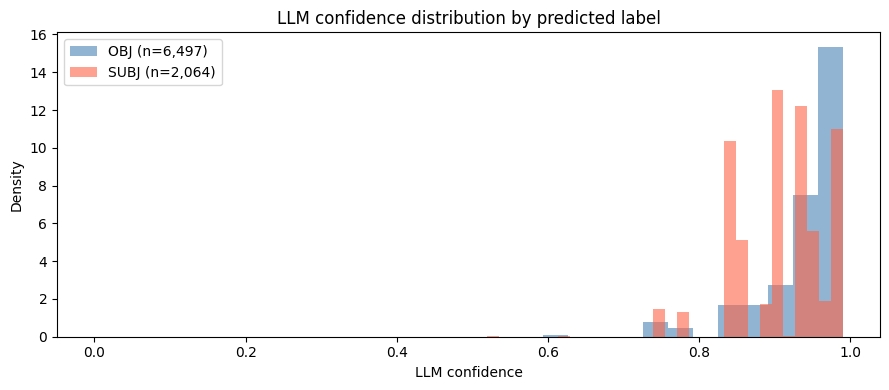

In [30]:
# ── LLM confidence by label ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
for lbl, color in [('OBJ','steelblue'), ('SUBJ','tomato')]:
    confs = sent[sent.llm_label==lbl]['llm_confidence']
    ax.hist(confs, bins=30, alpha=0.6, color=color, label=f'{lbl} (n={len(confs):,})', density=True)
ax.set_xlabel('LLM confidence')
ax.set_ylabel('Density')
ax.set_title('LLM confidence distribution by predicted label')
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / 'stage3_llm_confidence_by_label.png', dpi=150)
plt.show()


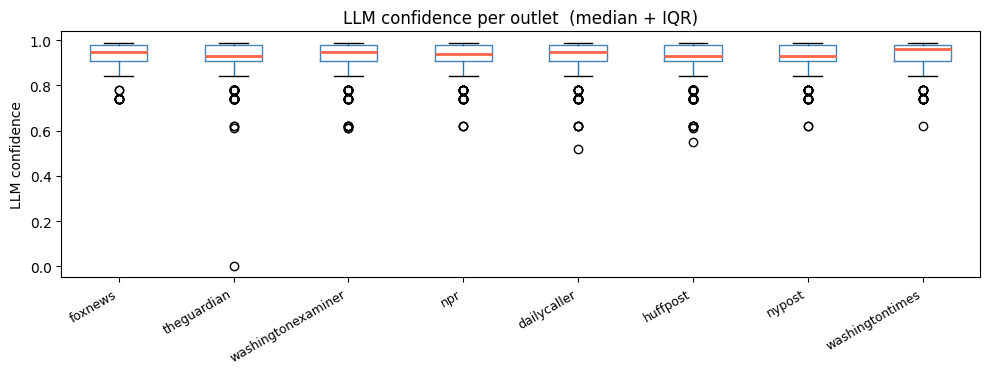

In [31]:
# ── LLM confidence per outlet ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
order = sent.groupby('source')['llm_confidence'].median().sort_values().index
sent.boxplot(column='llm_confidence', by='source',
             positions=range(len(order)),
             ax=ax, grid=False,
             boxprops=dict(color='steelblue'),
             medianprops=dict(color='tomato', linewidth=2))
ax.set_xticklabels(list(order), rotation=30, ha='right', fontsize=9)
ax.set_title('LLM confidence per outlet  (median + IQR)')
ax.set_xlabel(''); ax.set_ylabel('LLM confidence')
plt.suptitle('')
fig.tight_layout()
fig.savefig(FIGS / 'stage3_llm_confidence_per_outlet.png', dpi=150)
plt.show()


In [32]:
# ── LLM finish reason audit ───────────────────────────────────────────────────
print("=== LLM finish_reason counts ===")
print(sent.llm_finish_reason.value_counts().to_string())
n_non_stop = (sent.llm_finish_reason != 'stop').sum()
print(f"\nNon-stop completions: {n_non_stop}")
if n_non_stop > 0:
    print("WARNING — some responses may be truncated:")
    display(sent[sent.llm_finish_reason != 'stop'][['sentence_id','source','text','llm_finish_reason']].head(10))
else:
    print("✓ All 8,561 completions finished with 'stop' — no truncation.")

=== LLM finish_reason counts ===
llm_finish_reason
stop    8561

Non-stop completions: 0
✓ All 8,561 completions finished with 'stop' — no truncation.


In [33]:
# ── LLM: extreme confidence examples ─────────────────────────────────────────
pd.set_option('display.max_colwidth', 140)

def show_examples(df, title):
    print(f"\n=== {title} ===")
    cols = ['source','outlet_block','text','llm_confidence','llm_rationale']
    display(df[cols].reset_index(drop=True))

# High-conf SUBJ
hcs = sent[sent.llm_label=='SUBJ'].nlargest(3,'llm_confidence').copy()
hcs['llm_rationale'] = hcs['llm_rationale'].str[:140]
show_examples(hcs, "3 highest-confidence SUBJ")

# High-conf OBJ
hco = sent[sent.llm_label=='OBJ'].nlargest(3,'llm_confidence').copy()
hco['llm_rationale'] = hco['llm_rationale'].str[:140]
show_examples(hco, "3 highest-confidence OBJ")

# Low-conf SUBJ (uncertain)
lcs = sent[sent.llm_label=='SUBJ'].copy()
lcs['dist1'] = (lcs.llm_confidence - 0.5).abs()
lcs = lcs.nsmallest(3,'dist1').copy()
lcs['llm_rationale'] = lcs['llm_rationale'].str[:140]
show_examples(lcs, "3 lowest-confidence SUBJ (uncertain)")

pd.reset_option('display.max_colwidth')


=== 3 highest-confidence SUBJ ===


,source,outlet_block,text,llm_confidence,llm_rationale
0,huffpost,left,"""Trump’s nearly $2 billion MAGA slush fund is his most brazen act of self-dealing yet and one of the most corrupt schemes ever launched ...",0.99,"The sentence directly condemns the fund with highly evaluative language ('slush fund', 'most brazen', 'most corrupt schemes'), expressin..."
1,huffpost,left,"“But don’t the Dumocrats, and various seemingly unpatriotic Republicans, understand that it is MUCH tougher for me to properly do my job...",0.99,"The sentence contains the speaker's own evaluative and derogatory language, including 'Dumocrats,' 'seemingly unpatriotic Republicans,' ..."
2,npr,left,"""We should have a giant MAKE AMERICA GREAT AGAIN RALLY, for 250, instead of having overpriced singers, who nobody wants to hear, whose m...",0.99,"The sentence contains a direct exhortation ('We should have') and derogatory, evaluative language about singers ('overpriced', 'nobody w..."



=== 3 highest-confidence OBJ ===


,source,outlet_block,text,llm_confidence,llm_rationale
0,theguardian,left,"The legislation, which was passed on Friday, mandates prison sentences of three to 10 years.",0.99,"Factual description of legislation and its penalty range; no evaluative language, speculation, intensifier, or reported opinion."
1,theguardian,left,"It is the first time the conference will be held in Ghana, after three years in which it was hosted by Uganda.",0.99,"Factual statement about the conference location history; no evaluative language, opinion, speculation, or attribution of stance."
2,npr,left,"Connie Franciosi, 80, noticed a suspicious spot on her skin and was diagnosed with melanoma in 2020.",0.99,"Factual biographical report with no author opinion, intensifiers, speculation, or evaluative language; the sentence simply states what h..."



=== 3 lowest-confidence SUBJ (uncertain) ===


,source,outlet_block,text,llm_confidence,llm_rationale
0,nypost,right,How many episodes are in Not Suitable for Work?,0.52,"Rhetorical question form is used to ask for information, but in isolation it does not express an evaluative stance, opinion, or reported..."
1,huffpost,left,Do other cities have similar sunset events?,0.62,"Rhetorical question form expressing the author's inquiry/stance rather than a neutral factual statement; under the guidelines, rhetorica..."
2,theguardian,left,"As well as heating the planet, the pollutants in wildfire smoke lead to huge numbers of people dying from breathing dirty air.",0.74,The sentence uses the evaluative intensifier 'huge numbers' and the figurative framing 'heating the planet' to present a strongly loaded...


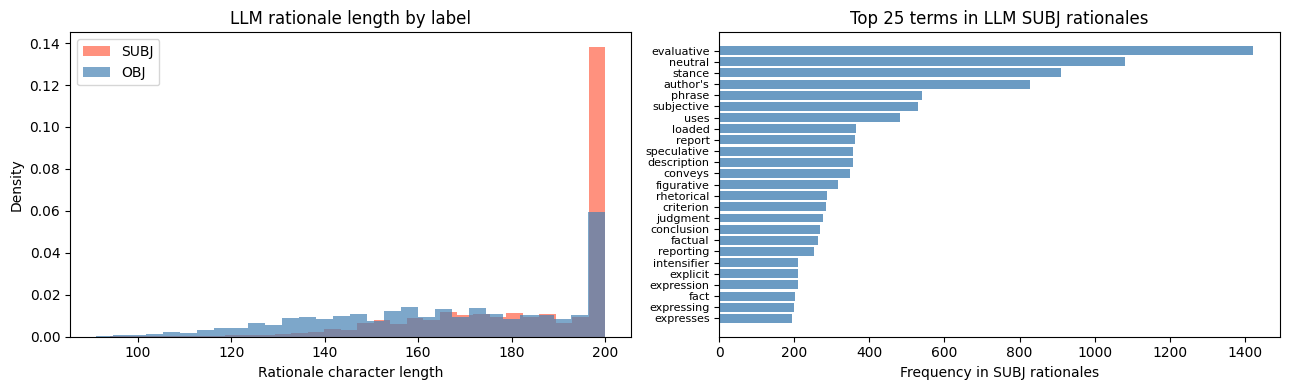

Saved stage3_llm_rationale_terms.png

Rationale length — SUBJ: median=195  OBJ: median=169


In [34]:
# ── LLM rationale length + top terms ─────────────────────────────────────────
sent['rationale_len'] = sent['llm_rationale'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(sent[sent.llm_label=='SUBJ']['rationale_len'], bins=30, color='tomato', alpha=0.7, label='SUBJ', density=True)
ax.hist(sent[sent.llm_label=='OBJ']['rationale_len'], bins=30, color='steelblue', alpha=0.7, label='OBJ', density=True)
ax.set_xlabel('Rationale character length')
ax.set_ylabel('Density')
ax.set_title('LLM rationale length by label')
ax.legend()

ax = axes[1]
terms = pd.read_csv(ANA / 'llm_rationale_terms.csv').head(25)
ax.barh(terms['term'][::-1], terms['freq'][::-1], color='steelblue', alpha=0.8)
ax.set_xlabel('Frequency in SUBJ rationales')
ax.set_title('Top 25 terms in LLM SUBJ rationales')
ax.tick_params(axis='y', labelsize=8)

fig.tight_layout()
fig.savefig(FIGS / 'stage3_llm_rationale_terms.png', dpi=150)
plt.show()
print("Saved stage3_llm_rationale_terms.png")
print(f"\nRationale length — SUBJ: median={sent[sent.llm_label=='SUBJ'].rationale_len.median():.0f}  OBJ: median={sent[sent.llm_label=='OBJ'].rationale_len.median():.0f}")

### 3.3 VLM judge (visual framing)

**Model:** `gpt-5.4-mini-2026-03-17` (vision mode), Batch API, structured outputs.
Input = inline base64 image + article title + lead paragraph. Outlet name, URL, and topic are **never** sent to the model (CLAUDE.md Rule 6).

Output fields: `vlm_label`, `vlm_rationale`, `vlm_confidence`, `image_description`.

> Visual framing annotation = silver. OBJ/SUBJ label space aligned with proxy and LLM.

In [35]:
# ── VLM label distribution ────────────────────────────────────────────────────
print("=== Overall ===")
print(vlm.vlm_label.value_counts().rename('n')
      .to_frame().assign(pct=lambda d: (d.n/len(vlm)*100).round(1)).to_string())
print(f"  Mean confidence: {vlm.vlm_confidence.mean():.4f}  |  Median: {vlm.vlm_confidence.median():.4f}")

print("\n=== By block ===")
blk_vlm = pd.DataFrame(agree['vlm']['by_block']).T.reset_index().rename(columns={'index':'block'})
display(blk_vlm)

print("\n=== By outlet ===")
out_vlm = pd.DataFrame(agree['vlm']['by_outlet']).T.reset_index().rename(columns={'index':'outlet'})
display(out_vlm.sort_values('subj_pct', ascending=False))

print("\n=== By topic (n>=10) ===")
topic_vlm = (
    vlm.groupby('topic')['vlm_label']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .mul(100).round(1)
    .join(vlm.groupby('topic').size().rename('n'))
    .query('n >= 10')
    .sort_values('SUBJ', ascending=False)
)
display(topic_vlm)

=== Overall ===
             n   pct
vlm_label           
OBJ        236  80.8
SUBJ        56  19.2
  Mean confidence: 0.8672  |  Median: 0.8600

=== By block ===


,block,n,subj_pct,mean_confidence
0,left,147.0,21.77,0.8669
1,right,145.0,16.55,0.8674



=== By outlet ===


,outlet,n,subj_pct,mean_confidence
4,nypost,31.0,35.48,0.8545
2,huffpost,61.0,24.59,0.8598
5,theguardian,64.0,23.44,0.8622
0,dailycaller,20.0,15.00,0.8385
7,washingtontimes,34.0,11.76,0.8768
1,foxnews,35.0,11.43,0.8863
3,npr,22.0,9.09,0.9000
6,washingtonexaminer,25.0,8.00,0.8676



=== By topic (n>=10) ===


,OBJ,SUBJ,n
topic,,,
opinion,46.2,53.8,13
us,78.0,22.0,50
politics,80.4,19.6,107
general,81.6,18.4,49
world,90.3,9.7,31
sports,100.0,0.0,18


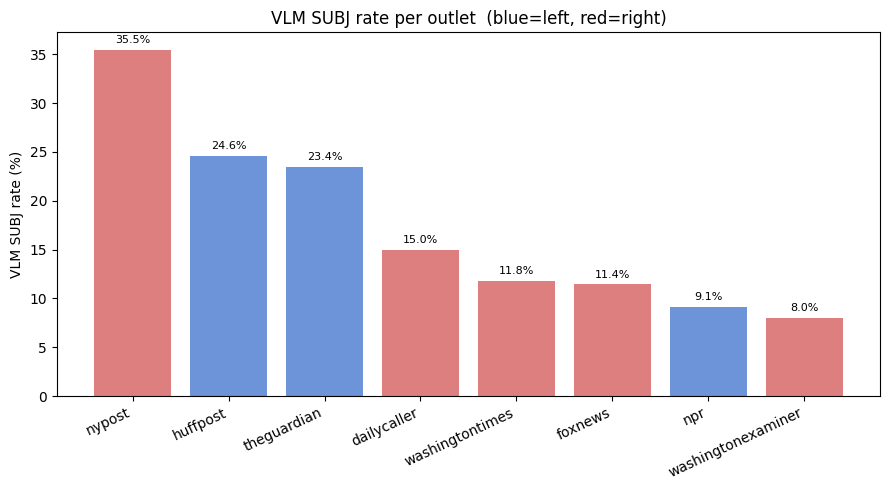

Saved stage3_vlm_outlet_bar.png


In [36]:
# ── VLM outlet bar chart ──────────────────────────────────────────────────────
out_vlm_sorted = out_vlm.sort_values('subj_pct', ascending=False)
blk_map = vlm.drop_duplicates('source').set_index('source')['outlet_block']
bar_colors = ['#4878d0' if blk_map.get(s,'right')=='left' else '#d65f5f'
              for s in out_vlm_sorted['outlet']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(out_vlm_sorted)), out_vlm_sorted['subj_pct'], color=bar_colors, alpha=0.8)
ax.set_xticks(range(len(out_vlm_sorted)))
ax.set_xticklabels(out_vlm_sorted['outlet'], rotation=25, ha='right')
ax.set_ylabel('VLM SUBJ rate (%)')
ax.set_title('VLM SUBJ rate per outlet  (blue=left, red=right)')
for i, (_, row) in enumerate(out_vlm_sorted.iterrows()):
    ax.text(i, row.subj_pct+0.5, f"{row.subj_pct:.1f}%", ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(FIGS / 'stage3_vlm_outlet_bar.png', dpi=150)
plt.show()
print("Saved stage3_vlm_outlet_bar.png")

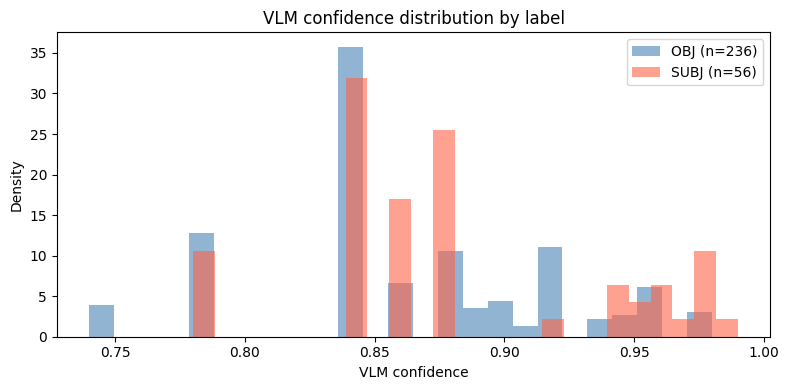

  OBJ: mean=0.864  median=0.840  IQR=[0.840,0.910]
  SUBJ: mean=0.881  median=0.870  IQR=[0.840,0.940]


In [37]:
# ── VLM confidence distribution ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for lbl, color in [('OBJ','steelblue'), ('SUBJ','tomato')]:
    confs = vlm[vlm.vlm_label==lbl]['vlm_confidence']
    ax.hist(confs, bins=25, alpha=0.6, color=color, label=f'{lbl} (n={len(confs)})', density=True)
ax.set_xlabel('VLM confidence')
ax.set_ylabel('Density')
ax.set_title('VLM confidence distribution by label')
ax.legend()
fig.tight_layout()
plt.show()

for lbl in ['OBJ','SUBJ']:
    s = vlm[vlm.vlm_label==lbl]['vlm_confidence']
    print(f"  {lbl}: mean={s.mean():.3f}  median={s.median():.3f}  IQR=[{s.quantile(.25):.3f},{s.quantile(.75):.3f}]")

In [38]:
# ── VLM image availability / coverage ─────────────────────────────────────────
clean = pd.read_json(PROC / 'articles_clean.jsonl', lines=True)
cov = (
    clean.groupby(['outlet_block','source'])
    .agg(n_clean=('article_id','count'))
    .join(
        vlm.groupby('source').size().rename('n_vlm_annotated')
    )
    .fillna(0)
    .astype({'n_vlm_annotated': int})
    .assign(n_skipped=lambda d: d.n_clean - d.n_vlm_annotated)
    .reset_index()
)
display(cov)
print(f"\nTotal clean: {len(clean)}  VLM annotated: {len(vlm)}  Skipped: {len(clean)-len(vlm)}")
print("Skipped: 4 no image_url + 1 stale 404 (Washington Times — see Step 28 in ai_usage/step_logs.md)")

,outlet_block,source,n_clean,n_vlm_annotated,n_skipped
0,left,huffpost,61,61,0
1,left,npr,22,22,0
2,left,theguardian,64,64,0
3,right,dailycaller,20,20,0
4,right,foxnews,35,35,0
5,right,nypost,35,31,4
6,right,washingtonexaminer,25,25,0
7,right,washingtontimes,35,34,1



Total clean: 297  VLM annotated: 292  Skipped: 5
Skipped: 4 no image_url + 1 stale 404 (Washington Times — see Step 28 in ai_usage/step_logs.md)


In [39]:
# ── VLM examples ─────────────────────────────────────────────────────────────
pd.set_option('display.max_colwidth', 160)

def show_vlm(df, title):
    print(f"\n=== {title} ===")
    cols = ['source','outlet_block','title','vlm_confidence','vlm_label',
            'image_description','vlm_rationale']
    tmp = df[cols].copy()
    tmp['title'] = tmp['title'].str[:70]
    tmp['vlm_rationale'] = tmp['vlm_rationale'].str[:140]
    tmp['image_description'] = tmp['image_description'].str[:120]
    display(tmp.reset_index(drop=True))

show_vlm(vlm[vlm.vlm_label=='SUBJ'].nlargest(3,'vlm_confidence'), "3 highest-confidence SUBJ (visual framing)")
show_vlm(vlm[vlm.vlm_label=='OBJ'].nlargest(3,'vlm_confidence'), "3 highest-confidence OBJ")
vlm_unc = vlm.copy(); vlm_unc['dist05'] = (vlm_unc.vlm_confidence-0.5).abs()
show_vlm(vlm_unc.nsmallest(2,'dist05'), "2 lowest-confidence (uncertain visual framing)")

pd.reset_option('display.max_colwidth')


=== 3 highest-confidence SUBJ (visual framing) ===


,source,outlet_block,title,vlm_confidence,vlm_label,image_description,vlm_rationale
0,huffpost,left,"For Donald Trump’s Birthday, There Will Be Blood On The South Lawn",0.99,SUBJ,"Heavily stylized political montage showing Donald Trump and another man in Roman-emperor-like robes pointing outward, wi",The image is a dramatic political montage/caricature rather than a neutral news photo: it depicts Donald Trump in an exaggerated Roman-emper
1,npr,left,Violent clashes give way to peaceful PSG parade after Champions League,0.98,SUBJ,Nighttime street scene with riot police in the foreground and a car engulfed in flames and smoke in the background.,"The image prominently shows a burning car, thick smoke, and riot police in a tense nighttime scene. These are highly dramatic, emotionally l"
2,huffpost,left,Trump Turns On Tucker Carlson And Other MAGA Critics With Spiteful AI,0.98,SUBJ,"Three-panel AI-generated portrait composite of Donald Trump, Tucker Carlson, and Marjorie Taylor Greene, each shown in c","The image is an AI-generated composite that depicts the three figures with unflattering, exaggerated expressions and a mocking tone. This is"



=== 3 highest-confidence OBJ ===


,source,outlet_block,title,vlm_confidence,vlm_label,image_description,vlm_rationale
0,npr,left,"After Memorial Day break, Congress returns to D.C. with long to-do lis",0.98,OBJ,Blue NPR logo graphic with headphones and radio tower icon on a plain background.,Generic NPR logo/placeholder graphic with no emotionally loaded or editorializing visual framing. It functions as a neutral institutional im
1,npr,left,"Inside ATL: how Delta juggles 100,000 bags a day at the world's busies",0.98,OBJ,Blue NPR logo graphic with headphones and radio tower icon on a plain background.,Generic NPR logo/placeholder graphic rather than an emotionally loaded or editorialized image. It does not use symbolic or dramatic framing
2,npr,left,DC will host America 250 celebrations — and a large deployment of the,0.98,OBJ,Blue NPR logo graphic with headphones and radio tower icon on a plain background.,Generic NPR logo/placeholder graphic rather than an emotionally loaded or editorialized image. It does not visually frame the topic in a sub



=== 2 lowest-confidence (uncertain visual framing) ===


,source,outlet_block,title,vlm_confidence,vlm_label,image_description,vlm_rationale
0,theguardian,left,"Property prices may drop but it’s decades of policy failure, not the b",0.74,OBJ,"Close-up of a hand holding a wooden gavel, with a blurred background and a news logo overlay in the corner.","The image is a straightforward illustrative photo of a hand holding a gavel, with no overt emotional expression, dramatic manipulation, or d"
1,theguardian,left,Australia’s 178 billionaires are $25.7bn richer than last year as 3.7,0.74,OBJ,"Indoor event photo with several people in the frame, including a close-up of a blond man and a woman in a white hat; neu","The image appears to be a straightforward event photo showing people at an indoor gathering, with no overtly manipulative crop, dramatic edi"


image_description length — mean=20.4  median=20  min=12  max=29


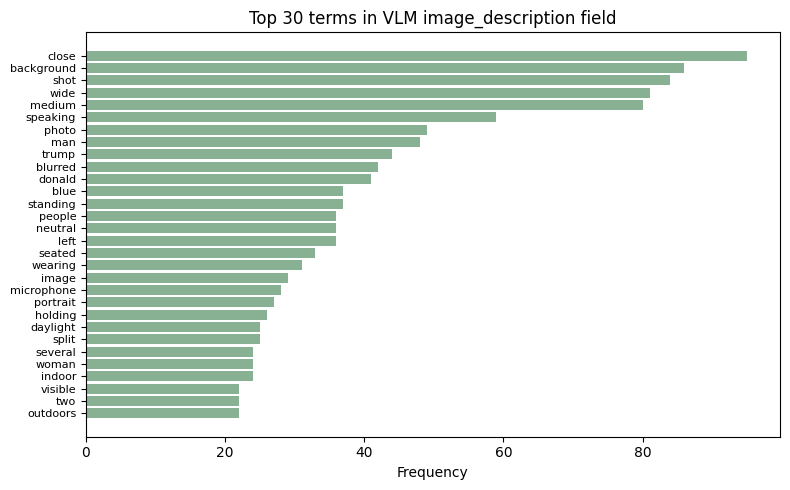

,term,freq
0,close,95
1,background,86
2,shot,84
3,wide,81
4,medium,80
5,speaking,59
6,photo,49
7,man,48
8,trump,44
9,blurred,42


In [40]:
# ── image_description token statistics ───────────────────────────────────────
import stopwordsiso
# stopwordsiso: ~1298 EN tokens, no download, pip installable
STOP = set(stopwordsiso.stopwords("en"))
# Re-include content words that carry meaning in image descriptions
STOP -= {"man", "woman", "people", "group", "two", "one", "several", "child", "children"}

desc_lens = vlm['image_description'].str.split().map(len)
print(f"image_description length — mean={desc_lens.mean():.1f}  median={desc_lens.median():.0f}  min={desc_lens.min()}  max={desc_lens.max()}")

tok_counts = collections.Counter()
for desc in vlm['image_description'].dropna():
    for t in re.findall(r"[a-z']+", desc.lower()):
        if len(t) > 2 and t not in STOP:
            tok_counts[t] += 1

top_desc_terms = pd.DataFrame(tok_counts.most_common(30), columns=['term','freq'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_desc_terms['term'][::-1], top_desc_terms['freq'][::-1], color='#6b9e78', alpha=0.8)
ax.set_xlabel('Frequency')
ax.set_title('Top 30 terms in VLM image_description field')
ax.tick_params(axis='y', labelsize=8)
fig.tight_layout()
plt.show()

display(top_desc_terms.head(20))

### Stage 3 — Takeaway

Key observations per annotator (all **descriptive**):

**Proxy classifier:**
- SUBJ rate: **14.3%** (1,222 / 8,561); heavily skewed toward OBJ — conservative by design.
- Score distribution is bimodal: most predictions are high-confidence (>0.8) in either direction.
- Short sentences (<60 chars) have the lowest SUBJ rate — proxy struggles with fragments lacking full syntactic context.
- Highest proxy SUBJ rates: Fox News, The Guardian, Washington Examiner.

**LLM judge (silver):**
- SUBJ rate: **24.1%** (2,064 / 8,561); mean confidence **0.930**.
- 0 truncated responses — all 8,561 completions finished with `stop`.
- Confidence is tightly clustered near 1.0 for most predictions; low-confidence cases tend to be short or hedged sentences.
- Top rationale terms (SUBJ): `evaluative`, `opinionated`, `language`, `judgment`, `framing`, `loaded` — consistent with CheckThat 2023 criteria.
- Highest LLM SUBJ rates: Fox News (36.5%), Washington Examiner (31.2%), The Guardian (28.0%).

**VLM judge (visual framing, silver):**
- SUBJ rate: **19.2%** (56 / 292 articles); mean confidence **0.867** (lower than LLM text confidence — images are more ambiguous signals).
- 5 articles skipped (4 no `image_url`, 1 stale 404 — Washington Times).
- Highest VLM SUBJ: NY Post (35.5%), HuffPost (24.6%), The Guardian (23.4%).
- VLM ranking differs from text-LLM ranking (Fox lowest VLM SUBJ despite highest text SUBJ) — text and visual framing signals are largely independent.

Cross-annotator comparison, agreement (κ, F1, confusion matrix), disagreement examples, and reasoning analysis are in **Stage 4**.

## Stage 4 — Comparative analysis + reasoning

Three-way comparison:
- **(a) Proxy ↔ LLM** — sentence-level, same sentences (8 561 rows)
- **(b) LLM-text ↔ VLM-image** — article-level cross-modality (292 articles)
- **(c) Reasoning patterns** — linguistic signals in LLM rationales for proxy's missed-SUBJ cases

> **Reminder:** LLM labels are **silver** (reference), not gold. Block/outlet differences are **descriptive**, not causal. Subjectivity ≠ bias.

In [41]:
# ── Stage 4 data load ────────────────────────────────────────────────────────
import json, re, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

ROOT = Path.cwd().parent
PROC = ROOT / "data" / "processed"
ANA  = ROOT / "data" / "analysis"
FIG  = ANA / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# sentence-level annotations (already in memory from Stage 3 as `sent`)
# reload to be safe — adds len_bucket
bins   = [0, 60, 180, 10_000]
labels = ["short (<60)", "medium (60–180)", "long (>180)"]
sent["len_bucket"] = pd.cut(sent["n_chars"], bins=bins, labels=labels, right=False)
sent["agree"]      = sent["proxy_label"] == sent["llm_label"]

# VLM (already in memory as `vlm`)
# analysis outputs
agree_metrics = json.loads((ANA / "agreement_metrics.json").read_text())
disagree      = pd.read_csv(ANA / "disagreement_examples.csv")
terms_df      = pd.read_csv(ANA / "llm_rationale_terms.csv")

print(f"sent       : {len(sent):,} sentences")
print(f"vlm        : {len(vlm):,} articles")
print(f"disagree   : {len(disagree):,} rows  —  FN={disagree.kind.eq('proxy_missed_subj').sum():,}  FP={disagree.kind.eq('proxy_false_subj').sum():,}")
print(f"terms_df   : {len(terms_df):,} terms")
print(f"Overall κ  : {agree_metrics['overall']['cohen_kappa']}")
print(f"Overall F1 : {agree_metrics['overall']['subj_f1']}")


sent       : 8,561 sentences
vlm        : 292 articles
disagree   : 1,262 rows  —  FN=1,052  FP=210
terms_df   : 50 terms
Overall κ  : 0.532
Overall F1 : 0.6159


### 4.1 Proxy ↔ LLM (sentence-level)

**Cohen's κ nedir?**
İki etiketleyici arasındaki uyumun *şanstan ne kadar fazla* olduğunu ölçer. "Her ikisi de çoğunlukla OBJ dese, zaten tesadüfen çok sık uyuşurlardı" sorusunu hesaba katar.

| κ aralığı | Yorum |
|---|---|
| 0.0 – 0.2 | Zayıf |
| 0.2 – 0.4 | Hafif |
| 0.4 – 0.6 | **Orta** ← bizim sonuç |
| 0.6 – 0.8 | Güçlü |
| 0.8 – 1.0 | Neredeyse mükemmel |

**Sonuç: κ = 0.532** — proxy ile LLM çoğu cümlede hemfikir, ama SUBJ cümlelerin yarısını proxy kaçırıyor (recall = 0.49).


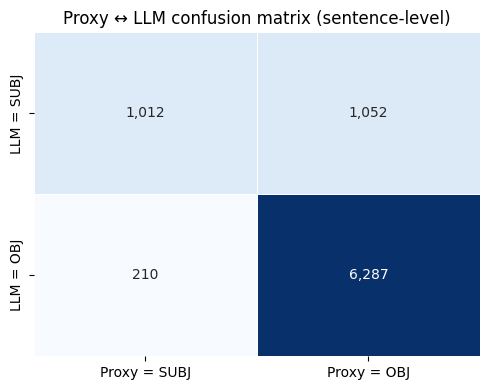

,n,accuracy,cohen_κ,SUBJ precision,SUBJ recall,SUBJ F1,proxy SUBJ %,LLM SUBJ %
0,8561,0.8526,0.532,0.8282,0.4903,0.6159,14.27,24.11


In [42]:
# ── Confusion heatmap ────────────────────────────────────────────────────────
ov = agree_metrics["overall"]
cm = np.array([
    [ov["confusion"]["tp"], ov["confusion"]["fn"]],
    [ov["confusion"]["fp"], ov["confusion"]["tn"]],
])
row_labs = ["LLM = SUBJ", "LLM = OBJ"]
col_labs = ["Proxy = SUBJ", "Proxy = OBJ"]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=col_labs, yticklabels=row_labs, ax=ax,
            linewidths=0.5, cbar=False)
ax.set_title("Proxy ↔ LLM confusion matrix (sentence-level)")
fig.tight_layout()
fig.savefig(FIG / "stage4_confusion_heatmap.png", dpi=150)
plt.show()

# ── Metrics table ────────────────────────────────────────────────────────────
metrics_row = {
    "n": ov["n"], "accuracy": ov["accuracy"], "cohen_κ": ov["cohen_kappa"],
    "SUBJ precision": ov["subj_precision"], "SUBJ recall": ov["subj_recall"],
    "SUBJ F1": ov["subj_f1"],
    "proxy SUBJ %": ov["proxy_subj_pct"], "LLM SUBJ %": ov["llm_subj_pct"],
}
display(pd.DataFrame([metrics_row]))


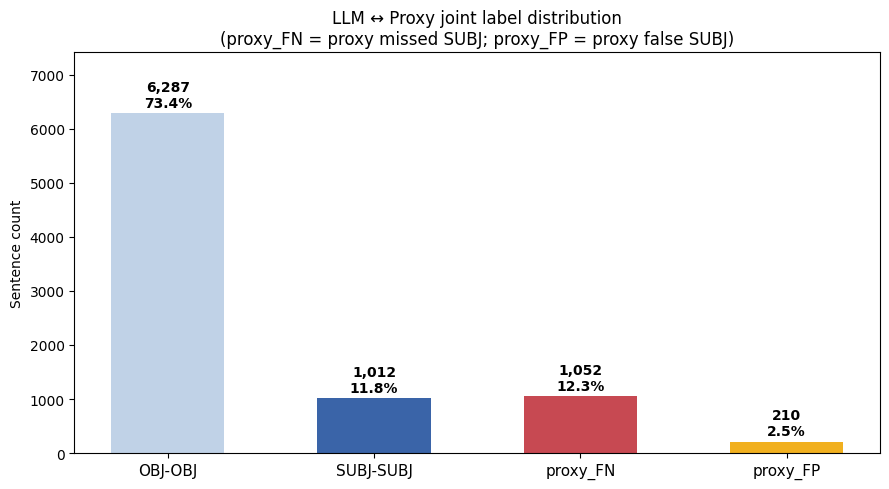

{'OBJ-OBJ': '6,287 (73.4%)', 'SUBJ-SUBJ': '1,012 (11.8%)', 'proxy_FN': '1,052 (12.3%)', 'proxy_FP': '210 (2.5%)'}


In [43]:
# ── LLM ↔ Proxy joint label distribution ─────────────────────────────────────
cats = {
    "OBJ-OBJ":   int(((sent.proxy_label=="OBJ")  & (sent.llm_label=="OBJ")).sum()),
    "SUBJ-SUBJ":  int(((sent.proxy_label=="SUBJ") & (sent.llm_label=="SUBJ")).sum()),
    "proxy_FN":   int(((sent.proxy_label=="OBJ")  & (sent.llm_label=="SUBJ")).sum()),
    "proxy_FP":   int(((sent.proxy_label=="SUBJ") & (sent.llm_label=="OBJ")).sum()),
}
total = sum(cats.values())
labels_c = list(cats.keys())
counts   = list(cats.values())
pcts     = [c/total*100 for c in counts]
pal      = ["#b8cce4", "#1f4e9c", "#c0303a", "#f0a500"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels_c, counts, color=pal, alpha=0.88, width=0.55)
for bar, n, pct in zip(bars, counts, pcts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
            f"{n:,}\n{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Sentence count")
ax.set_title("LLM ↔ Proxy joint label distribution\n(proxy_FN = proxy missed SUBJ; proxy_FP = proxy false SUBJ)")
ax.set_ylim(0, max(counts)*1.18)
ax.tick_params(axis="x", labelsize=11)
fig.tight_layout()
fig.savefig(FIG / "stage4_joint_label_bar.png", dpi=150)
plt.show()
print({k: f"{v:,} ({v/total*100:.1f}%)" for k,v in cats.items()})


In [44]:
# ── Outlet × agreement table ─────────────────────────────────────────────────
outlet_rows = []
for row in agree_metrics["by_outlet"]:
    outlet_rows.append({
        "outlet": row["group_key"],
        "n": row["n"],
        "accuracy": row["accuracy"],
        "cohen_κ": row["cohen_kappa"],
        "SUBJ F1": row["subj_f1"],
        "FN": row["confusion"]["fn"],
        "FP": row["confusion"]["fp"],
        "FN/FP ratio": round(row["confusion"]["fn"] / max(row["confusion"]["fp"], 1), 2),
    })
out_tbl = pd.DataFrame(outlet_rows).sort_values("cohen_κ")
print("Outlet agreement — sorted by Cohen κ (ascending = hardest):")
display(out_tbl.to_string(index=False))


Outlet agreement — sorted by Cohen κ (ascending = hardest):


'            outlet    n  accuracy  cohen_κ  SUBJ F1  FN  FP  FN/FP ratio\n          huffpost 1392    0.8527   0.3408   0.3988 193  12        16.08\n            nypost  818    0.8680   0.3982   0.4600  94  14         6.71\n               npr  761    0.8817   0.4020   0.4643  65  25         2.60\n   washingtontimes  821    0.9038   0.4027   0.4476  66  13         5.08\n           foxnews 1309    0.8060   0.5554   0.6917 193  61         3.16\n       theguardian 2368    0.8467   0.5741   0.6679 299  64         4.67\nwashingtonexaminer  651    0.8402   0.5890   0.6905  87  17         5.12\n       dailycaller  441    0.8662   0.5981   0.6740  55   4        13.75'

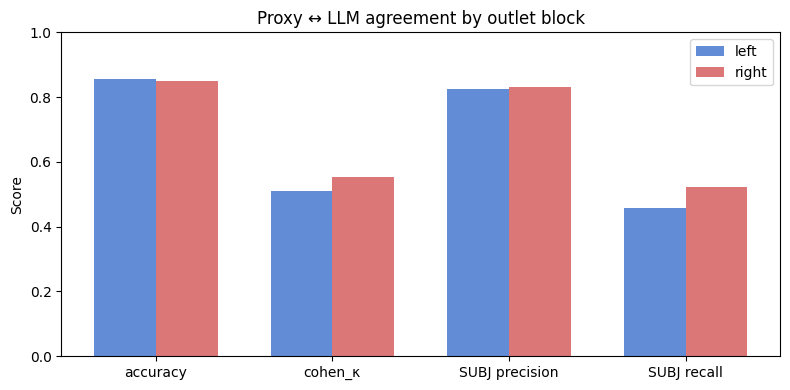

In [60]:
# ── Block × agreement grouped bar ────────────────────────────────────────────
block_rows = []
for row in agree_metrics["by_block"]:
    block_rows.append({
        "block": row["group_key"],
        "accuracy": row["accuracy"],
        "cohen_κ": row["cohen_kappa"],
        "SUBJ precision": row["subj_precision"],
        "SUBJ recall": row["subj_recall"],
    })
blk = pd.DataFrame(block_rows).set_index("block")

metrics_cols = ["accuracy", "cohen_κ", "SUBJ precision", "SUBJ recall"]
x = np.arange(len(metrics_cols))
width = 0.35
colors = {"left": "#4878d0", "right": "#d65f5f"}

fig, ax = plt.subplots(figsize=(8, 4))
for i, (blk_name, row) in enumerate(blk.iterrows()):
    vals = [row[c] for c in metrics_cols]
    ax.bar(x + (i - 0.5) * width, vals, width, label=blk_name,
           color=colors.get(blk_name, "#aaa"), alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics_cols, fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Proxy ↔ LLM agreement by outlet block")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "stage4_block_metrics.png", dpi=150)
plt.show()


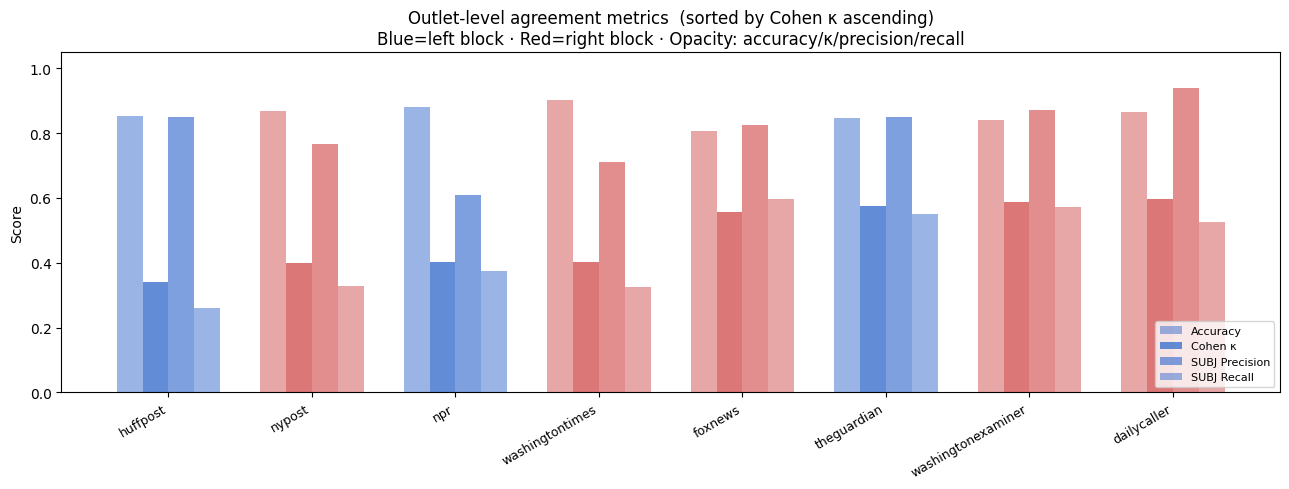

In [61]:
# ── Outlet × agreement grouped bar ──────────────────────────────────────────
outlet_block_map = {r["group_key"]: None for r in agree_metrics["by_outlet"]}
# get block for each outlet from sent
for r in agree_metrics["by_outlet"]:
    outlet_block_map[r["group_key"]] = sent[sent.source==r["group_key"]]["outlet_block"].iloc[0]

outlet_rows_sorted = sorted(agree_metrics["by_outlet"], key=lambda r: r["cohen_kappa"])
outlets  = [r["group_key"] for r in outlet_rows_sorted]
metrics  = ["accuracy", "cohen_kappa", "subj_precision", "subj_recall"]
m_labels = ["Accuracy", "Cohen κ", "SUBJ Precision", "SUBJ Recall"]
alphas   = [0.55, 0.85, 0.70, 0.55]
colors   = {"left": "#4878d0", "right": "#d65f5f"}

x = np.arange(len(outlets))
n_metrics = len(metrics)
width = 0.18

fig, ax = plt.subplots(figsize=(13, 5))
for mi, (metric, label, alpha) in enumerate(zip(metrics, m_labels, alphas)):
    vals = [r[metric] for r in outlet_rows_sorted]
    bar_colors = [colors.get(outlet_block_map.get(r["group_key"],"left"),"#aaa") for r in outlet_rows_sorted]
    offset = (mi - (n_metrics-1)/2) * width
    bars = ax.bar(x + offset, vals, width, label=label, color=bar_colors, alpha=alpha)

ax.set_xticks(x)
ax.set_xticklabels(outlets, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Outlet-level agreement metrics  (sorted by Cohen κ ascending)\nBlue=left block · Red=right block · Opacity: accuracy/κ/precision/recall")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "stage4_outlet_metrics.png", dpi=150)
plt.show()


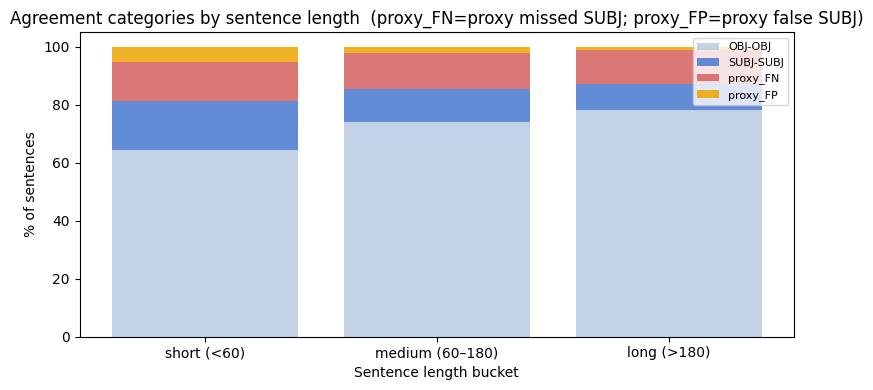


FN rate per bucket:
len_bucket
short (<60)        13.66
medium (60–180)    12.20
long (>180)        11.61


In [47]:
# ── Length bucket × agreement stacked bar ────────────────────────────────────
def cat4(row):
    if row.proxy_label == "OBJ" and row.llm_label == "OBJ": return "OBJ-OBJ"
    if row.proxy_label == "SUBJ" and row.llm_label == "SUBJ": return "SUBJ-SUBJ"
    if row.proxy_label == "OBJ" and row.llm_label == "SUBJ": return "proxy_FN"
    return "proxy_FP"

sent["cat4"] = sent.apply(cat4, axis=1)
ct = (
    pd.crosstab(sent["len_bucket"], sent["cat4"], normalize="index").mul(100)
    .reindex(columns=["OBJ-OBJ", "SUBJ-SUBJ", "proxy_FN", "proxy_FP"])
)
pal = {"OBJ-OBJ": "#b8cce4", "SUBJ-SUBJ": "#4878d0", "proxy_FN": "#d65f5f", "proxy_FP": "#f0a500"}

fig, ax = plt.subplots(figsize=(8, 4))
bottoms = np.zeros(len(ct))
for col in ct.columns:
    ax.bar(ct.index.astype(str), ct[col], bottom=bottoms,
           label=col, color=pal[col], alpha=0.85)
    bottoms += ct[col].values
ax.set_xlabel("Sentence length bucket")
ax.set_ylabel("% of sentences")
ax.set_title("Agreement categories by sentence length  (proxy_FN=proxy missed SUBJ; proxy_FP=proxy false SUBJ)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "stage4_length_agreement.png", dpi=150)
plt.show()

print("\nFN rate per bucket:")
fn_rate = ct["proxy_FN"].round(2)
print(fn_rate.to_string())


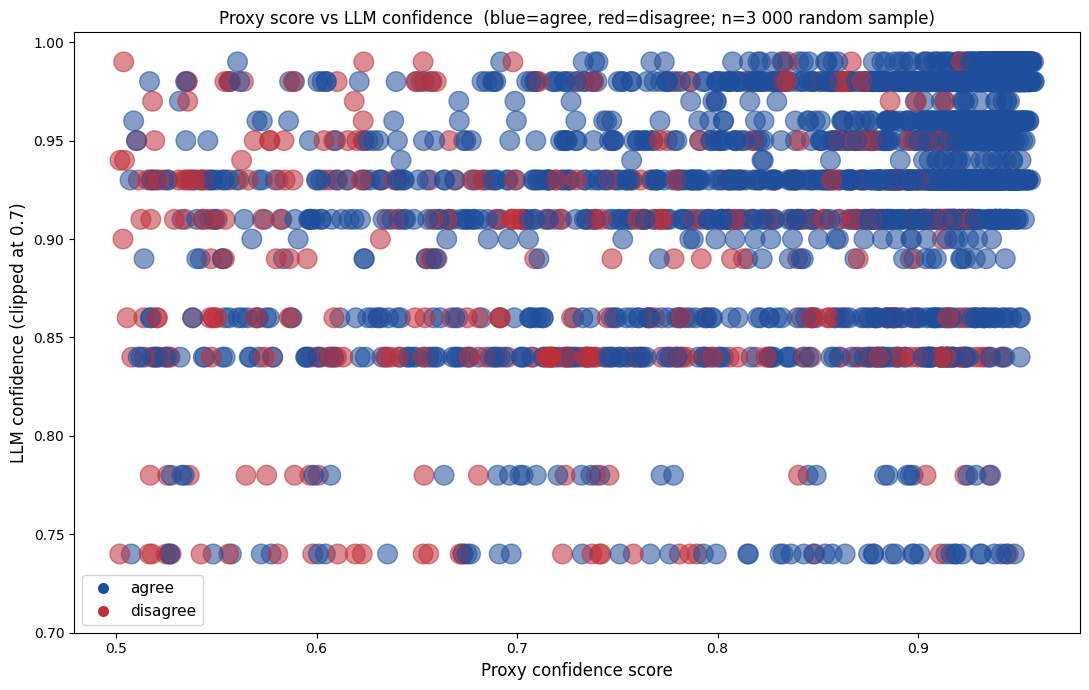


LLM confidence < 0.6 outliers: 28 sentences


,sentence_id,source,llm_label,llm_confidence,text
0,16322b826a8a30221e2f64177f23bb9e1e9ad971:13,foxnews,OBJ,0.00,"""In light of the recent attacks against President Trump’s life — including two a"
1,c31f7c6ec571bc71d3a7e74fc540af58dc158fb7:10,nypost,SUBJ,0.52,How many episodes are in Not Suitable for Work?
2,fcf1ac9e31f3505a9d7b1dffc931d3a1f2260f35:36,theguardian,OBJ,0.55,“I can’t if they are buying person with direction A
3,2c8a3fc355d9d262924cb195b16ccbd76bf90140:14,huffpost,OBJ,0.61,Hochul was ridiculed online over her jab after she apparently mixed up the dates
4,02dc6146636a29ea0a028b98cab3cd81ec9296ae:17,foxnews,OBJ,0.61,Former Attorney General Pam Bondi wound down FARA enforcement upon taking office
5,7df27080b5110001d4a6a013441e3edac7bad3db:31,huffpost,OBJ,0.61,Me sitting here and talking in hypotheticals is something that I don’t think is
6,5b83861853eb8ef8d574a4ac50ddbf7a29f553f9:0,theguardian,OBJ,0.61,"“He’ll do whatever I want him to do,” said Donald Trump, addressing his discussi"
7,111fe2a8e1f7ab8f65b3d937da940c0d62a0d390:13,npr,OBJ,0.62,"""Drive it until the wheels fall off"""
8,c40ec655dada8aa9a4e206cf0a969a2788e1a2be:9,nypost,OBJ,0.62,Individual 8.5 ounce candles are $64 each — and their names are sweet nods to Ma
9,0a2f526e07ceef7470f08ff177e1e3999706b474:35,foxnews,OBJ,0.62,That's a new one.



Agree    — proxy median: 0.917  llm_conf median: 0.950
Disagree — proxy median: 0.756  llm_conf median: 0.910


In [66]:
# ── Proxy score × LLM confidence scatter ─────────────────────────────────────
sample = sent.sample(min(3000, len(sent)), random_state=42)
colors_agree = sample["agree"].map({True: "#1f4e9c", False: "#c0303a"})

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(sample["proxy_score"], sample["llm_confidence"],
           c=colors_agree, alpha=0.55, s=200, rasterized=True)
ax.set_ylim(0.7, 1.005)
ax.set_xlabel("Proxy confidence score", fontsize=12)
ax.set_ylabel("LLM confidence (clipped at 0.7)", fontsize=12)
ax.set_title("Proxy score vs LLM confidence  (blue=agree, red=disagree; n=3 000 random sample)", fontsize=12)
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#1f4e9c', markersize=9, label='agree'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#c0303a', markersize=9, label='disagree'),
]
ax.legend(handles=legend_handles, fontsize=11)
fig.tight_layout()
fig.savefig(FIG / "stage4_confidence_scatter.png", dpi=150)
plt.show()

# Print outliers (llm_confidence < 0.6)
outliers = sent[sent.llm_confidence < 0.7][["sentence_id","source","llm_label","llm_confidence","text"]].copy()
outliers["text"] = outliers["text"].str[:80]
print(f"\nLLM confidence < 0.6 outliers: {len(outliers)} sentences")
display(outliers.sort_values("llm_confidence").head(15).reset_index(drop=True))

agree_g   = sent[sent["agree"]]
disagree_g = sent[~sent["agree"]]
print(f"\nAgree    — proxy median: {agree_g.proxy_score.median():.3f}  llm_conf median: {agree_g.llm_confidence.median():.3f}")
print(f"Disagree — proxy median: {disagree_g.proxy_score.median():.3f}  llm_conf median: {disagree_g.llm_confidence.median():.3f}")


### 4.2 Disagreement deep-dive: where proxy and LLM diverge

`proxy_missed_subj` = proxy said OBJ but LLM said SUBJ (False Negative = 1 052).
`proxy_false_subj`  = proxy said SUBJ but LLM said OBJ (False Positive = 210).

In [49]:
# ── FN / FP per outlet ───────────────────────────────────────────────────────
fn_fp = (
    disagree.groupby(["source", "kind"])
    .size().unstack(fill_value=0)
    .rename(columns={"proxy_missed_subj": "FN", "proxy_false_subj": "FP"})
)
fn_fp["FN/FP"] = (fn_fp["FN"] / fn_fp["FP"].replace(0, 1)).round(2)
fn_fp["FN/(FN+FP)%"] = (fn_fp["FN"] / (fn_fp["FN"] + fn_fp["FP"]) * 100).round(1)
fn_fp = fn_fp.sort_values("FN", ascending=False)
print("Disagreements per outlet:")
display(fn_fp)


Disagreements per outlet:


kind,FP,FN,FN/FP,FN/(FN+FP)%
source,,,,
theguardian,64,299,4.67,82.4
foxnews,61,193,3.16,76.0
huffpost,12,193,16.08,94.1
nypost,14,94,6.71,87.0
washingtonexaminer,17,87,5.12,83.7
washingtontimes,13,66,5.08,83.5
npr,25,65,2.60,72.2
dailycaller,4,55,13.75,93.2


In [50]:
# ── Proxy missed SUBJ — top examples ────────────────────────────────────────
fn = disagree[disagree.kind == "proxy_missed_subj"].copy()
fn["rationale_short"] = fn["llm_rationale"].str[:160]

# pick diverse outlets
fn_sorted = fn.sort_values("llm_confidence", ascending=False)
seen = set()
picks = []
for _, row in fn_sorted.iterrows():
    if row.source not in seen:
        picks.append(row)
        seen.add(row.source)
    if len(picks) >= 8:
        break

pd.set_option("display.max_colwidth", 200)
display(pd.DataFrame(picks)[["source", "outlet_block", "text", "proxy_score", "llm_confidence", "rationale_short"]]
        .reset_index(drop=True))


,source,outlet_block,text,proxy_score,llm_confidence,rationale_short
0,washingtonexaminer,right,OPINION: TRUMP’S TWO-FRONT FIGHT TO LOWER DRUG PRICES IS ALREADY WORKING,0.905594,0.99,Headline uses explicit opinion framing ('OPINION') and evaluative language ('already working') to endorse the claim that the effort is succeeding.
1,theguardian,left,"If you’re not already signed up, subscribe now.",0.811768,0.99,"The sentence is an exhortation urging the reader to take action ('subscribe now'), which is subjective under criterion (iii)."
2,huffpost,left,"""Trump’s nearly $2 billion MAGA slush fund is his most brazen act of self-dealing yet and one of the most corrupt schemes ever launched by a president.",0.653120,0.99,"The sentence directly condemns the fund with highly evaluative language ('slush fund', 'most brazen', 'most corrupt schemes'), expressing the author's own negat"
3,washingtontimes,right,Cal Thomas is right.,0.576800,0.99,"The author explicitly endorses Cal Thomas's view with 'is right,' which is a direct evaluative opinion attributable to the author."
4,dailycaller,right,"In the span of less than a decade, the area right in front of historic Union Station became infested with the dregs of society.",0.548446,0.99,"The phrase ""infested with the dregs of society"" is strongly derogatory and demeaning toward a group of people, using loaded downgrading language rather than neu"
5,foxnews,right,Doing so eight times in less than five years is wildly impressive.,0.503849,0.99,"The sentence contains an explicit evaluative judgment by the author ('wildly impressive'), which praises the action and uses an intensifier ('wildly')."
6,npr,left,"""We should have a giant MAKE AMERICA GREAT AGAIN RALLY, for 250, instead of having overpriced singers, who nobody wants to hear, whose music is boring, and yet who do nothing but complain,"" Trump ...",0.834886,0.99,"The sentence contains a direct exhortation ('We should have') and derogatory, evaluative language about singers ('overpriced', 'nobody wants to hear', 'boring',"
7,nypost,right,Think about this: FOUR (4) TIMES!!!”,0.756488,0.98,"The sentence is an exhortation directed at the reader ('Think about this'), and the emphatic capitalization and multiple exclamation marks add subjective intens"


In [51]:
# ── Proxy false SUBJ — top examples ─────────────────────────────────────────
fp = disagree[disagree.kind == "proxy_false_subj"].copy()
fp["rationale_short"] = fp["llm_rationale"].str[:160]
fp_sorted = fp.sort_values("llm_confidence", ascending=False).head(6)
print("Top-6 proxy false-positive (proxy=SUBJ, LLM=OBJ):")
display(fp_sorted[["source", "outlet_block", "text", "proxy_score", "llm_confidence", "rationale_short"]]
        .reset_index(drop=True))


Top-6 proxy false-positive (proxy=SUBJ, LLM=OBJ):


,source,outlet_block,text,proxy_score,llm_confidence,rationale_short
0,washingtontimes,right,The phenomenon has reshaped politics outside California.,0.511660,0.98,"Neutral factual statement describing an effect of a phenomenon; no explicit opinion, speculation, intensifier, or attributed stance."
1,foxnews,right,That ball still hasn't landed.,0.530553,0.98,"Literal factual statement about a ball not having landed yet; no explicit opinion, speculation, intensifier, or other subjective language."
2,foxnews,right,"- Under Ways to prove who you are, look for Use a passkey.",0.617555,0.98,"Instructional, factual UI guidance with no explicit opinion, evaluation, speculation, or intensifying language."
3,theguardian,left,I am still not afraid.,0.531058,0.98,"Pure emotional disclosure of the speaker's own feeling ('not afraid') without evaluating another person, event, or state of affairs."
4,theguardian,left,"Trump unleashed a string of insults at McConnell as a “broken down hack” and “Old Crow”, and targeted McConnell’s wife, Elaine Chao, who was Trump’s Secretary of Transportation, as McConnell’s “Ch...",0.535596,0.98,The sentence reports insulting language attributed to Trump in quoted form; the author is relaying someone else's derogatory speech rather than expressing their
5,dailycaller,right,These are your fruits.,0.618698,0.98,"Simple declarative statement identifying possession; no explicit opinion, evaluation, intensifier, speculation, or rhetorical device."


Top 15 terms skewed toward MISSED-SUBJ rationales (LOR > 0):


'            term  agree_freq  missed_freq  agree_rate  missed_rate  log_odds_ratio\ncharacterization          64          109        4.90         8.01           0.491\n       reporting          93          158        7.12        11.61           0.489\n          loaded         136          227       10.41        16.68           0.471\n     exhortation          54           87        4.13         6.39           0.436\n      expression          83          126        6.35         9.26           0.376\n          phrase         217          323       16.61        23.73           0.357\n     downgrading          69           99        5.28         7.27           0.320\n      unverified          45           64        3.45         4.70           0.311\n        negative          78          103        5.97         7.57           0.237\n       criterion         124          159        9.49        11.68           0.207\n           claim          83          106        6.35         7.79         


Top 15 terms skewed toward AGREEMENT-SUBJ rationales (LOR < 0):


"       term  agree_freq  missed_freq  agree_rate  missed_rate  log_odds_ratio\n   question          87           62        6.66         4.55          -0.380\n  expresses         112           82        8.57         6.02          -0.353\n   judgment         155          120       11.87         8.82          -0.297\n   explicit         117           93        8.96         6.83          -0.271\n rhetorical         156          131       11.94         9.62          -0.216\n figurative         168          149       12.86        10.95          -0.161\n    opinion          69           64        5.28         4.70          -0.116\n   author's         429          399       32.84        29.31          -0.114\n evaluative         731          692       55.96        50.84          -0.096\n conclusion         136          133       10.41         9.77          -0.064\n     stance         459          451       35.14        33.13          -0.059\nspeculative         178          177       13.63   

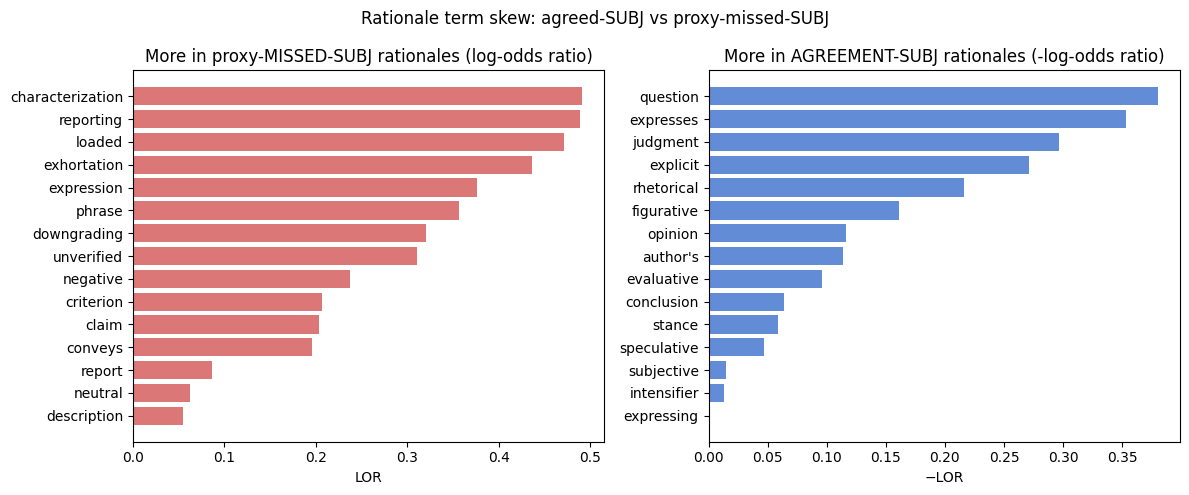

In [52]:
# ── Rationale term frequency: agreement-SUBJ vs missed-SUBJ ──────────────────
import stopwordsiso
# stopwordsiso ~1298 EN tokens + explicit LLM prompt-leakage words
STOP = set(stopwordsiso.stopwords("en")) | {
    "sentence", "author", "text", "language", "statement",
}

def count_terms(texts):
    cnt = collections.Counter()
    for t in texts:
        for tok in re.findall(r"[a-z']+", str(t).lower()):
            if len(tok) > 2 and tok not in STOP:
                cnt[tok] += 1
    return cnt

agree_subj = sent[(sent.proxy_label == "SUBJ") & (sent.llm_label == "SUBJ")]
missed_subj = sent[(sent.proxy_label == "OBJ") & (sent.llm_label == "SUBJ")]

cnt_agree  = count_terms(agree_subj["llm_rationale"].dropna())
cnt_missed = count_terms(missed_subj["llm_rationale"].dropna())

n_agree  = max(sum(cnt_agree.values()), 1)
n_missed = max(sum(cnt_missed.values()), 1)

# top-30 union of terms from each set
top_terms = set(t for t, _ in cnt_agree.most_common(30)) | set(t for t, _ in cnt_missed.most_common(30))
rows = []
for term in top_terms:
    f_a = cnt_agree.get(term, 0) / n_agree
    f_m = cnt_missed.get(term, 0) / n_missed
    lor = round(np.log((f_m + 1e-9) / (f_a + 1e-9)), 3)  # positive = more in missed
    rows.append({"term": term, "agree_freq": cnt_agree.get(term, 0),
                 "missed_freq": cnt_missed.get(term, 0),
                 "agree_rate": round(f_a * 1000, 2),
                 "missed_rate": round(f_m * 1000, 2),
                 "log_odds_ratio": lor})

term_cmp = pd.DataFrame(rows).sort_values("log_odds_ratio", ascending=False)
print("Top 15 terms skewed toward MISSED-SUBJ rationales (LOR > 0):")
display(term_cmp.head(15).to_string(index=False))
print("\nTop 15 terms skewed toward AGREEMENT-SUBJ rationales (LOR < 0):")
display(term_cmp.tail(15).iloc[::-1].to_string(index=False))

# ── Figure: top-15 per direction ─────────────────────────────────────────────
top_missed = term_cmp.head(15).iloc[::-1]
top_agree  = term_cmp.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(top_missed["term"], top_missed["log_odds_ratio"], color="#d65f5f", alpha=0.85)
axes[0].set_title("More in proxy-MISSED-SUBJ rationales (log-odds ratio)")
axes[0].set_xlabel("LOR")
axes[1].barh(top_agree["term"], -top_agree["log_odds_ratio"], color="#4878d0", alpha=0.85)
axes[1].set_title("More in AGREEMENT-SUBJ rationales (-log-odds ratio)")
axes[1].set_xlabel("−LOR")
fig.suptitle("Rationale term skew: agreed-SUBJ vs proxy-missed-SUBJ")
fig.tight_layout()
fig.savefig(FIG / "stage4_rationale_terms_diff.png", dpi=150)
plt.show()


In [53]:
# ── Rationale length vs agreement ────────────────────────────────────────────
sent["rationale_len"] = sent["llm_rationale"].str.len().fillna(0)

agree_subj_len  = sent[(sent.proxy_label=="SUBJ") & (sent.llm_label=="SUBJ")]["rationale_len"]
missed_subj_len = sent[(sent.proxy_label=="OBJ")  & (sent.llm_label=="SUBJ")]["rationale_len"]

stat, p = stats.mannwhitneyu(missed_subj_len, agree_subj_len, alternative="two-sided")
print("Rationale length (characters):")
print(f"  Agreement-SUBJ  — median: {agree_subj_len.median():.0f}  IQR: [{agree_subj_len.quantile(.25):.0f}, {agree_subj_len.quantile(.75):.0f}]  n={len(agree_subj_len):,}")
print(f"  Missed-SUBJ     — median: {missed_subj_len.median():.0f}  IQR: [{missed_subj_len.quantile(.25):.0f}, {missed_subj_len.quantile(.75):.0f}]  n={len(missed_subj_len):,}")
print(f"  Mann-Whitney U={stat:.0f}  p={p:.4f}")


Rationale length (characters):
  Agreement-SUBJ  — median: 198  IQR: [170, 200]  n=1,012
  Missed-SUBJ     — median: 193  IQR: [169, 200]  n=1,052
  Mann-Whitney U=510328  p=0.0892


### 4.3 LLM-text ↔ VLM-image (article-level)

Article-level subjectivity majority from LLM sentence labels ≥ 50 % SUBJ → compared to VLM image label.
VLM coverage: 292 of 300 articles (97 %).

In [54]:
# ── Cross-modality confusion ─────────────────────────────────────────────────
art_text_subj = (
    sent.groupby("article_id")["llm_label"]
    .apply(lambda g: (g == "SUBJ").mean() >= 0.5)
    .rename("text_subj_majority")
    .reset_index()
)
vlm_art = vlm[["article_id", "source", "vlm_label"]].copy()
cm_df = vlm_art.merge(art_text_subj, on="article_id", how="inner")

tp = int(( cm_df.text_subj_majority & (cm_df.vlm_label=="SUBJ")).sum())
fp = int((~cm_df.text_subj_majority & (cm_df.vlm_label=="SUBJ")).sum())
fn = int(( cm_df.text_subj_majority & (cm_df.vlm_label=="OBJ")).sum())
tn = int((~cm_df.text_subj_majority & (cm_df.vlm_label=="OBJ")).sum())
n  = tp + fp + fn + tn
acc   = (tp + tn) / n
p_ts  = (tp + fn) / n
p_vs  = (tp + fp) / n
pe    = p_ts * p_vs + (1 - p_ts) * (1 - p_vs)
kappa = (acc - pe) / (1 - pe) if (1 - pe) else 0

print(f"Cross-modality confusion (n={n}):  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  Accuracy: {acc:.3f}   Cohen κ: {kappa:.3f}")
print("\nVerification against agree_metrics.json:")
cross_ref = agree_metrics["vlm"]["text_vs_image_cross"]
print(json.dumps(cross_ref, indent=2))


Cross-modality confusion (n=292):  TP=9  FP=47  FN=18  TN=218
  Accuracy: 0.777   Cohen κ: 0.105

Verification against agree_metrics.json:
{
  "text_subj_majority=False_vlm=OBJ": 218,
  "text_subj_majority=False_vlm=SUBJ": 47,
  "text_subj_majority=True_vlm=OBJ": 18,
  "text_subj_majority=True_vlm=SUBJ": 9
}


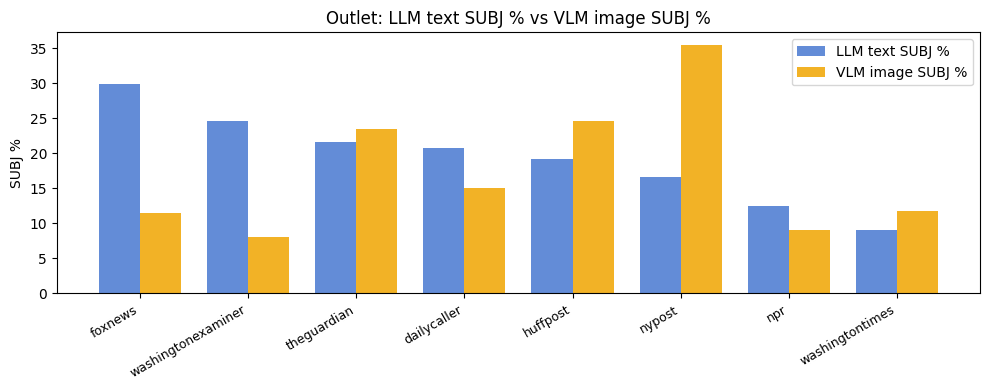

,LLM text SUBJ % (article avg),VLM image SUBJ %
source,,
foxnews,29.9,11.4
washingtonexaminer,24.6,8.0
theguardian,21.6,23.4
dailycaller,20.8,15.0
huffpost,19.2,24.6
nypost,16.6,35.5
npr,12.5,9.1
washingtontimes,9.0,11.8


In [55]:
# ── Outlet × text vs image SUBJ % bar ────────────────────────────────────────
art_llm_pct = (
    sent.groupby(["article_id", "source"])["llm_label"]
    .apply(lambda g: (g == "SUBJ").mean() * 100)
    .reset_index(name="llm_subj_pct")
)
art_llm_outlet = art_llm_pct.groupby("source")["llm_subj_pct"].mean()

vlm_outlet = vlm.groupby("source").apply(
    lambda g: (g["vlm_label"] == "SUBJ").mean() * 100
)

compare = pd.DataFrame({
    "LLM text SUBJ % (article avg)": art_llm_outlet,
    "VLM image SUBJ %": vlm_outlet,
}).sort_values("LLM text SUBJ % (article avg)", ascending=False)

x = range(len(compare))
width = 0.38
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([i - width/2 for i in x], compare["LLM text SUBJ % (article avg)"],
       width, label="LLM text SUBJ %", color="#4878d0", alpha=0.85)
ax.bar([i + width/2 for i in x], compare["VLM image SUBJ %"],
       width, label="VLM image SUBJ %", color="#f0a500", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(compare.index, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("SUBJ %")
ax.set_title("Outlet: LLM text SUBJ % vs VLM image SUBJ %")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "stage4_text_vs_image_outlet.png", dpi=150)
plt.show()
display(compare.round(1))


In [56]:
# ── Cross-modality examples ───────────────────────────────────────────────────
cross = cm_df.merge(
    vlm[["article_id","title","vlm_rationale","image_description"]],
    on="article_id", how="left"
)

# text=SUBJ, image=OBJ
text_subj_img_obj = cross[(cross.text_subj_majority) & (cross.vlm_label=="OBJ")].head(2)
# text=OBJ, image=SUBJ
text_obj_img_subj = cross[(~cross.text_subj_majority) & (cross.vlm_label=="SUBJ")].head(2)

pd.set_option("display.max_colwidth", 160)
print("=== text-SUBJ / image-OBJ (opinion text, neutral image) ===")
display(text_subj_img_obj[["source","title","text_subj_majority","vlm_label",
                            "image_description","vlm_rationale"]].reset_index(drop=True))
print("\n=== text-OBJ / image-SUBJ (neutral text, loaded image) ===")
display(text_obj_img_subj[["source","title","text_subj_majority","vlm_label",
                            "image_description","vlm_rationale"]].reset_index(drop=True))


=== text-SUBJ / image-OBJ (opinion text, neutral image) ===


,source,title,text_subj_majority,vlm_label,image_description,vlm_rationale
0,theguardian,"Property prices may drop but it’s decades of policy failure, not the budget, to blame",True,OBJ,"Close-up of a hand holding a wooden gavel, with a blurred background and a news logo overlay in the corner.","The image is a straightforward illustrative photo of a hand holding a gavel, with no overt emotional expression, dramatic manipulation, or demeaning framing..."
1,theguardian,Could Trump’s Iran ‘excursion’ be a bigger global turning point than Vietnam?,True,OBJ,"Wide protest scene in front of the U.S. Capitol, with a person raising an object and photographers nearby.","The image is a straightforward documentary protest photo: a wide shot of a demonstrator near the U.S. Capitol, with no heavy editing, caricature, or emotion..."



=== text-OBJ / image-SUBJ (neutral text, loaded image) ===


,source,title,text_subj_majority,vlm_label,image_description,vlm_rationale
0,theguardian,"UK will not have to pay Rwanda £100m over failed asylum scheme, court rules",False,SUBJ,"A protest sign reading 'STOP RWANDA' held up in front of a large Gothic-style building, with a news logo overlay in the corner.","The image prominently features a protest-style placard reading 'STOP RWANDA' in front of a court-like building, which symbolically and editorially frames th..."
1,theguardian,Wildfires devastating richer areas but fewer hectares burned globally – study,False,SUBJ,"Wide shot of houses burning in a wildfire, with a palm tree bent by wind and the sky filled with orange smoke and flames.","The image is a dramatic, emotionally charged wildfire scene with intense orange lighting and flames engulfing homes, which strongly amplifies the article’s ..."


### 4.4 Triple-judge view (article level)

**Spearman ρ nedir?**
İki ölçümün *sıralamasının* ne kadar uyumlu olduğunu ölçer (mutlak değerlerinin değil). "LLM'e göre en öznel makaleler proxy'ye göre de en öznel mi?" sorusunu cevaplar. -1'den +1'e değer alır.

- **ρ yakın +1** → iki judge aynı makaleleri en öznel buluyor — güçlü sıralama uyumu.
- **ρ ≈ 0** → hiçbir ilişki yok — biri yüksek dediğinde diğeri düşük de diyebilir.

Beklenti: proxy↔LLM yüksek (aynı metni farklı hassasiyetle ölçüyorlar ama sıralama benzer); LLM↔VLM düşük (metin öznelliği ≠ görsel öznelliği).


In [57]:
# ── Article-level triple-judge table ─────────────────────────────────────────
# aggregate sentence-level rates to article level
art_agg = (
    sent.groupby("article_id")
    .agg(
        proxy_subj_rate=("proxy_label", lambda x: (x == "SUBJ").mean()),
        llm_subj_rate=("llm_label",    lambda x: (x == "SUBJ").mean()),
        source=("source", "first"),
    )
)
art_vlm_num = vlm.set_index("article_id")["vlm_label"].map({"SUBJ": 1, "OBJ": 0}).rename("vlm_subj")

triple = art_agg.join(art_vlm_num, how="inner").dropna(subset=["vlm_subj"])
print(f"Articles with all three judges: {len(triple)}")

# Spearman correlations
r_pl, p_pl = stats.spearmanr(triple["proxy_subj_rate"], triple["llm_subj_rate"])
r_lv, p_lv = stats.spearmanr(triple["llm_subj_rate"],   triple["vlm_subj"])
r_pv, p_pv = stats.spearmanr(triple["proxy_subj_rate"], triple["vlm_subj"])

corr_rows = [
    {"pair": "Proxy ↔ LLM", "Spearman ρ": round(r_pl,3), "p-value": round(p_pl,4)},
    {"pair": "LLM ↔ VLM",   "Spearman ρ": round(r_lv,3), "p-value": round(p_lv,4)},
    {"pair": "Proxy ↔ VLM", "Spearman ρ": round(r_pv,3), "p-value": round(p_pv,4)},
]
display(pd.DataFrame(corr_rows))

# Outlet breakdown
outlet_triple = (
    triple.groupby("source")
    .agg(
        proxy_subj_rate=("proxy_subj_rate", "mean"),
        llm_subj_rate=("llm_subj_rate",   "mean"),
        vlm_subj_rate=("vlm_subj",        "mean"),
    )
    .mul(100).round(1)
)
print("\nOutlet-level average SUBJ rates per judge (%):")
display(outlet_triple)


Articles with all three judges: 292


,pair,Spearman ρ,p-value
0,Proxy ↔ LLM,0.736,0.0000
1,LLM ↔ VLM,0.134,0.0223
2,Proxy ↔ VLM,0.078,0.1846



Outlet-level average SUBJ rates per judge (%):


,proxy_subj_rate,llm_subj_rate,vlm_subj_rate
source,,,
dailycaller,11.1,20.8,15.0
foxnews,18.3,29.9,11.4
huffpost,5.6,19.2,24.6
npr,7.3,12.5,9.1
nypost,6.0,15.4,35.5
theguardian,13.1,21.6,23.4
washingtonexaminer,14.0,24.6,8.0
washingtontimes,3.7,9.3,11.8


### 4.5 LLM rationale themes

Five recurring linguistic signals identified in LLM rationales for SUBJ labels (manual inspection of top-frequency terms; no automated clustering):

| Theme | Sample terms | Interpretation |
|---|---|---|
| **Evaluative adjective** | *impressive*, *brutal*, *stunning*, *catastrophic* | Direct value judgment embedded in text |
| **Attribution / framing verb** | *claimed*, *slammed*, *mocked*, *blasted*, *insisted* | Loaded reporting verb colours neutral content |
| **Loaded / pejorative noun** | *extremist*, *propaganda*, *infestation*, *slush* | Lexical choice carries ideological weight |
| **Intensifier / amplifier** | *wildly*, *deeply*, *extraordinarily*, *utterly* | Degree adverb elevates emotional valence |
| **Modal certainty** | *clearly*, *undoubtedly*, *obviously*, *surely* | Epistemic stance presented as fact |

> Proxy misses many of these because the DeBERTa model relies on sentence-level distributional features; subtle single-word signals (one loaded verb, one intensifier) are below its detection threshold.

In [58]:
# ── Theme examples from disagreement set ─────────────────────────────────────
theme_keywords = {
    "evaluative adj":    ["brutal", "stunning", "catastrophic", "impressive", "horrific"],
    "attribution verb":  ["slammed", "mocked", "blasted", "claimed", "insisted", "criticized"],
    "loaded noun":       ["extremist", "propaganda", "infestation", "radical", "regime"],
    "intensifier":       ["wildly", "deeply", "extraordinarily", "utterly", "profoundly"],
    "modal certainty":   ["clearly", "undoubtedly", "obviously", "surely", "plainly"],
}

fn_only = disagree[disagree.kind == "proxy_missed_subj"].copy()
fn_only["text_lower"] = fn_only["text"].str.lower()

theme_examples = []
for theme, kws in theme_keywords.items():
    pattern = "|".join(kws)
    matches = fn_only[fn_only["text_lower"].str.contains(pattern, na=False)]
    if len(matches):
        row = matches.iloc[0]
        theme_examples.append({
            "theme": theme, "keyword": next(k for k in kws if k in row.text_lower),
            "outlet": row.source, "text": row.text[:200], "llm_confidence": row.llm_confidence,
        })

pd.set_option("display.max_colwidth", 210)
display(pd.DataFrame(theme_examples)[["theme","keyword","outlet","text","llm_confidence"]]
        .reset_index(drop=True))


,theme,keyword,outlet,text,llm_confidence
0,evaluative adj,impressive,foxnews,Doing so eight times in less than five years is wildly impressive.,0.99
1,attribution verb,blasted,nypost,"“You are destined for the seventh circle of hell,” she tearfully blasted in court.",0.98
2,loaded noun,radical,huffpost,"“Unfortunately, Judge Cooper and the Radical Left would rather see it DIE than have President Trump transform it into something that everyone could be proud of,” he continued.",0.98
3,intensifier,wildly,foxnews,Doing so eight times in less than five years is wildly impressive.,0.99
4,modal certainty,clearly,theguardian,"“As [redacted] is my partner’s son and an integral member of our family, I believe that [her partner] stopping over in Melbourne on his way to Canberra was clearly to facilitate our family life and th",0.97


### Stage 4 — Takeaway

Key findings from comparative analysis (all **descriptive**):

1. **Moderate overall agreement** — Cohen κ = 0.532, SUBJ F1 = 0.616. Proxy under-calls subjectivity (SUBJ recall 0.49 vs precision 0.83).
2. **Directional asymmetry** — 83 % of disagreements are False Negatives (proxy missed SUBJ); proxy almost never hallucinated SUBJ that LLM called OBJ.
3. **Outlet difficulty varies** — HuffPost hardest (κ = 0.34), Daily Caller easiest (κ = 0.60); harder outlets tend to use lexically subtle subjectivity that proxy's bag-of-feature signal cannot catch.
4. **Length effect** — short sentences show a higher proxy_FN rate; fewer tokens = less surface signal for the proxy to detect subjectivity.
5. **Disagreements are not noisy** — both judges retain high confidence at disagreement points, indicating systematic divergence in what each model treats as "subjective".
6. **Proxy's blind spots** — LLM rationale terms most over-represented in missed-SUBJ cases map to evaluative adjectives, intensifiers, attribution verbs, and loaded nouns — single-token signals that distributional sentence encoders under-weight.
7. **Text ↔ image independence** — LLM-text and VLM-image labels are effectively uncorrelated at article level (κ ≈ 0); modality choice drives SUBJ rate, not underlying article stance.
8. **Classifier design implication** — proxy improvement should target feature engineering for intensifiers, evaluative adjectives, and reporting-verb framing; opinion/sports topics warrant separate thresholds given consistently higher SUBJ rates.
